In [548]:
import pandas as pd
import numpy as np
import seaborn as sns
import pandera.pandas as pa
import matplotlib.pyplot as plt
import joblib
from scipy import stats
from sklearn.metrics import adjusted_rand_score
from scipy.stats import normaltest
from matplotlib.patches import Patch
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import silhouette_samples
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA



pd.set_option('display.float_format', '{:.2f}'.format)

<h2 style="text-align: center">DATA LOADING</h2>

In [549]:
DATA_PATH = "../data/online_retail_II.xlsx"

df = pd.read_excel(DATA_PATH, sheet_name=0, dtype={"Customer ID": str})

In [550]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085,United Kingdom


In [551]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  str           
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), object(3), str(2)
memory usage: 32.1+ MB


In [552]:
df.describe()

,Quantity,InvoiceDate,Price
count,525461.00,525461,525461.00
mean,10.34,2010-06-28 11:37:36.845018,4.69
min,-9600.00,2009-12-01 07:45:00,-53594.36
25%,1.00,2010-03-21 12:20:00,1.25
50%,3.00,2010-07-06 09:51:00,2.10
75%,10.00,2010-10-15 12:45:00,4.21
max,19152.00,2010-12-09 20:01:00,25111.09
std,107.42,NaN,146.13


In [553]:
df.describe(include=['object', 'str'])

,Invoice,StockCode,Description,Customer ID,Country
count,525461,525461,522533,417534,525461
unique,28816,4632,4681,4383,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,14911,United Kingdom
freq,675,3516,3549,5710,485852


In [554]:
# schema validation before data cleaning (so nulls are allowed)


schema_raw = pa.DataFrameSchema({
    "Customer ID": pa.Column(str, nullable=True),
    "Invoice": pa.Column(object, nullable=True),
    "Quantity": pa.Column(int, nullable=True),
    "Price": pa.Column(float, nullable=True),
    "InvoiceDate": pa.Column("datetime64[us]", nullable=True),
    "Country": pa.Column(str, nullable=True),
    "Description": pa.Column(object, nullable=True),
    "StockCode": pa.Column(object, nullable=True)
})
schema_raw.validate(df)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530,United Kingdom


<h2 style="text-align: center">DATA CLEANING</h2>

In [555]:
df[df["Customer ID"].isna()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom


In [556]:
df[df["Quantity"] < 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592,United Kingdom


In [557]:
df[df["Price"] < 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [558]:
df["Invoice"] = df["Invoice"].astype("str")

df[df["Invoice"].str.match("^\\d{6}$") == False]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321,Australia
...,...,...,...,...,...,...,...,...
524695,C538123,22956,36 FOIL HEART CAKE CASES,-2,2010-12-09 15:41:00,2.10,12605,Germany
524696,C538124,M,Manual,-4,2010-12-09 15:43:00,0.50,15329,United Kingdom
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,15329,United Kingdom
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,15329,United Kingdom


In [559]:
df["Invoice"].str.replace("[0-9]", "", regex=True).unique()

# unique Invoice prefixes values

<StringArray>
['', 'C', 'A']
Length: 3, dtype: str

In [560]:
df[df["Invoice"].str.startswith("A", na = False)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [561]:
df["StockCode"] = df["StockCode"].astype("str")

df[(df["StockCode"].str.match("^\\d{5}$") == False) & (df["StockCode"].str.match("^\\d{5}[a-zA-Z]+$") == False)]["StockCode"].unique()

# this regex is for StockCode values that are not 5 digits or 5 digits followed by letters, which are the valid formats for StockCode. 
# So it reveals all the anomalous/non-standard stock codes

<StringArray>
[        'POST',            'D',     'DCGS0058',     'DCGS0068',
          'DOT',            'M',     'DCGS0004',     'DCGS0076',
           'C2', 'BANK CHARGES',     'DCGS0003',      'TEST001',
 'gift_0001_80',     'DCGS0072', 'gift_0001_20',     'DCGS0044',
      'TEST002', 'gift_0001_10', 'gift_0001_50',    'DCGS0066N',
 'gift_0001_30',         'PADS',       'ADJUST', 'gift_0001_40',
 'gift_0001_60', 'gift_0001_70', 'gift_0001_90',    'DCGSSGIRL',
     'DCGS0006',     'DCGS0016',     'DCGS0027',     'DCGS0036',
     'DCGS0039',     'DCGS0060',     'DCGS0056',     'DCGS0059',
         'GIFT',     'DCGSLBOY',            'm',     'DCGS0053',
     'DCGS0062',     'DCGS0037',     'DCGSSBOY',    'DCGSLGIRL',
            'S',     'DCGS0069',     'DCGS0070',     'DCGS0075',
            'B',     'DCGS0041',      'ADJUST2',      '47503J ',
           'C3',       'SP1002',    'AMAZONFEE']
Length: 55, dtype: str

In [562]:
df[df["StockCode"].str.contains("^DOT")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
2379,489597,DOT,DOTCOM POSTAGE,1,2009-12-01 14:28:00,647.19,NaN,United Kingdom
2539,489600,DOT,DOTCOM POSTAGE,1,2009-12-01 14:43:00,55.96,NaN,United Kingdom
2551,489601,DOT,DOTCOM POSTAGE,1,2009-12-01 14:44:00,68.39,NaN,United Kingdom
2571,489602,DOT,DOTCOM POSTAGE,1,2009-12-01 14:45:00,59.35,NaN,United Kingdom
2619,489603,DOT,DOTCOM POSTAGE,1,2009-12-01 14:46:00,42.39,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
524272,538071,DOT,DOTCOM POSTAGE,1,2010-12-09 14:09:00,885.94,NaN,United Kingdom
524887,538148,DOT,DOTCOM POSTAGE,1,2010-12-09 16:26:00,547.32,NaN,United Kingdom
525000,538149,DOT,DOTCOM POSTAGE,1,2010-12-09 16:27:00,620.68,NaN,United Kingdom
525126,538153,DOT,DOTCOM POSTAGE,1,2010-12-09 16:31:00,822.94,NaN,United Kingdom


In [563]:
cleaned_df = df.copy()

In [564]:
# Actual cleaning starts:

cleaned_df["Invoice"] = cleaned_df["Invoice"].astype("str")

# filtering expression:

mask = (
    cleaned_df["Invoice"].str.match("^\\d{6}$") == True
)

cleaned_df = cleaned_df[mask]

cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530,United Kingdom


In [565]:
cleaned_df["StockCode"] = cleaned_df["StockCode"].astype("str")

mask = (
    (cleaned_df["StockCode"].str.match("^\\d{5}$") == True)
    | (cleaned_df["StockCode"].str.match("^\\d{5}[a-zA-Z]+$") == True)
)

cleaned_df = cleaned_df[mask]

cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530,United Kingdom


In [566]:
cleaned_df.dropna(subset=["Customer ID"], inplace=True)

In [567]:
cleaned_df.dropna(subset=["InvoiceDate"], inplace=True)

In [568]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price
count,406323.00,406323,406323.00
mean,13.62,2010-07-01 10:14:46.649094,2.99
min,1.00,2009-12-01 07:45:00,0.00
25%,2.00,2010-03-26 14:01:00,1.25
50%,5.00,2010-07-09 15:48:00,1.95
75%,12.00,2010-10-14 17:09:00,3.75
max,19152.00,2010-12-09 20:01:00,295.00
std,97.00,NaN,4.29


In [569]:
len(cleaned_df[cleaned_df["Price"] == 0])

28

In [570]:
cleaned_df = cleaned_df[cleaned_df["Price"] > 0]

In [571]:
cleaned_df = cleaned_df[cleaned_df["Quantity"] > 0]

DESCRIPTION, STOCKCODE ARE NEVER USED AFTER DATA CLEANING IN THIS PROJECT, SO THERE IS NO POINT IN FILTERING THEM, LIKEWISE COUNTRY IS ALSO NEVER USED BECAUSE IT WOULD BE HEAVILY DISTORTED BY ONE COUNTRY (UK)

In [572]:
cleaned_df.drop_duplicates(inplace=True) 

# dropping duplicates

In [573]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price
count,399552.00,399552,399552.00
mean,13.80,2010-07-01 05:02:02.543548,3.00
min,1.00,2009-12-01 07:45:00,0.03
25%,2.00,2010-03-26 13:42:00,1.25
50%,5.00,2010-07-09 10:26:00,1.95
75%,12.00,2010-10-14 14:08:00,3.75
max,19152.00,2010-12-09 20:01:00,295.00
std,97.80,NaN,4.31


In [574]:
cleaned_df["Price"].min()

np.float64(0.03)

In [575]:
# Schema validation after cleaning (so nulls are not allowed)

schema_cleaned = pa.DataFrameSchema({
    "Customer ID": pa.Column(str, nullable=False),
    "Invoice": pa.Column(str, nullable=False),
    "Quantity": pa.Column(int, pa.Check.greater_than(0), nullable=False),
    "Price": pa.Column(float, pa.Check.greater_than(0), nullable=False),
    "Description": pa.Column(object, nullable=False),
    "StockCode": pa.Column(str, nullable=False),
    "InvoiceDate": pa.Column("datetime64[us]", nullable=False),
    "Country": pa.Column(str, nullable=False),
})
schema_cleaned.validate(cleaned_df)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530,United Kingdom


In [576]:
len(cleaned_df)/len(df)

0.7603837392308849

**FINAL RESULT:** 
DROPPED ABOUT 24 % OF THE RECORDS

<h2 style="text-align: center">FEATURE ENGINEERING</h2>

**FEATURES**: RECENCY, FREQUENCY, MONETARY, AOV, TENURE

In [577]:
cleaned_df["SalesLineTotal"] = cleaned_df["Quantity"] * cleaned_df["Price"] # total revenue for each individual transaction row.

cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SalesLineTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530,United Kingdom,5.90
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530,United Kingdom,3.75
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530,United Kingdom,3.75
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530,United Kingdom,7.50


In [578]:
aggregated_df = cleaned_df.groupby(by="Customer ID", as_index=False) \
    .agg(
        MonetaryValue=("SalesLineTotal", "sum"),
        Frequency=("Invoice", "nunique"),
        LastInvoiceDate=("InvoiceDate", "max"),
        FirstInvoiceDate=("InvoiceDate", "min")
    )

aggregated_df.head(5)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,FirstInvoiceDate
0,12346,169.36,2,2010-06-28 13:53:00,2010-03-02 13:08:00
1,12347,1323.32,2,2010-12-07 14:57:00,2010-10-31 14:20:00
2,12348,221.16,1,2010-09-27 14:59:00,2010-09-27 14:59:00
3,12349,2221.14,2,2010-10-28 08:23:00,2010-04-29 13:20:00
4,12351,300.93,1,2010-11-29 15:23:00,2010-11-29 15:23:00


In [579]:
max_invoice_date = aggregated_df["LastInvoiceDate"].max()

aggregated_df["Recency"] = (max_invoice_date - aggregated_df["LastInvoiceDate"]).dt.days
aggregated_df["Tenure"] = (aggregated_df["LastInvoiceDate"] - aggregated_df["FirstInvoiceDate"]).dt.days
aggregated_df["AOV"] = aggregated_df["MonetaryValue"] / aggregated_df["Frequency"]
aggregated_df.drop(columns=["LastInvoiceDate", "FirstInvoiceDate"], inplace=True)

aggregated_df.head(5)

,Customer ID,MonetaryValue,Frequency,Recency,Tenure,AOV
0,12346,169.36,2,164,118,84.68
1,12347,1323.32,2,2,37,661.66
2,12348,221.16,1,73,0,221.16
3,12349,2221.14,2,42,181,1110.57
4,12351,300.93,1,10,0,300.93


<h2 style="text-align: center">VISUALIZATION BEFORE TRANSFORMING</h2>

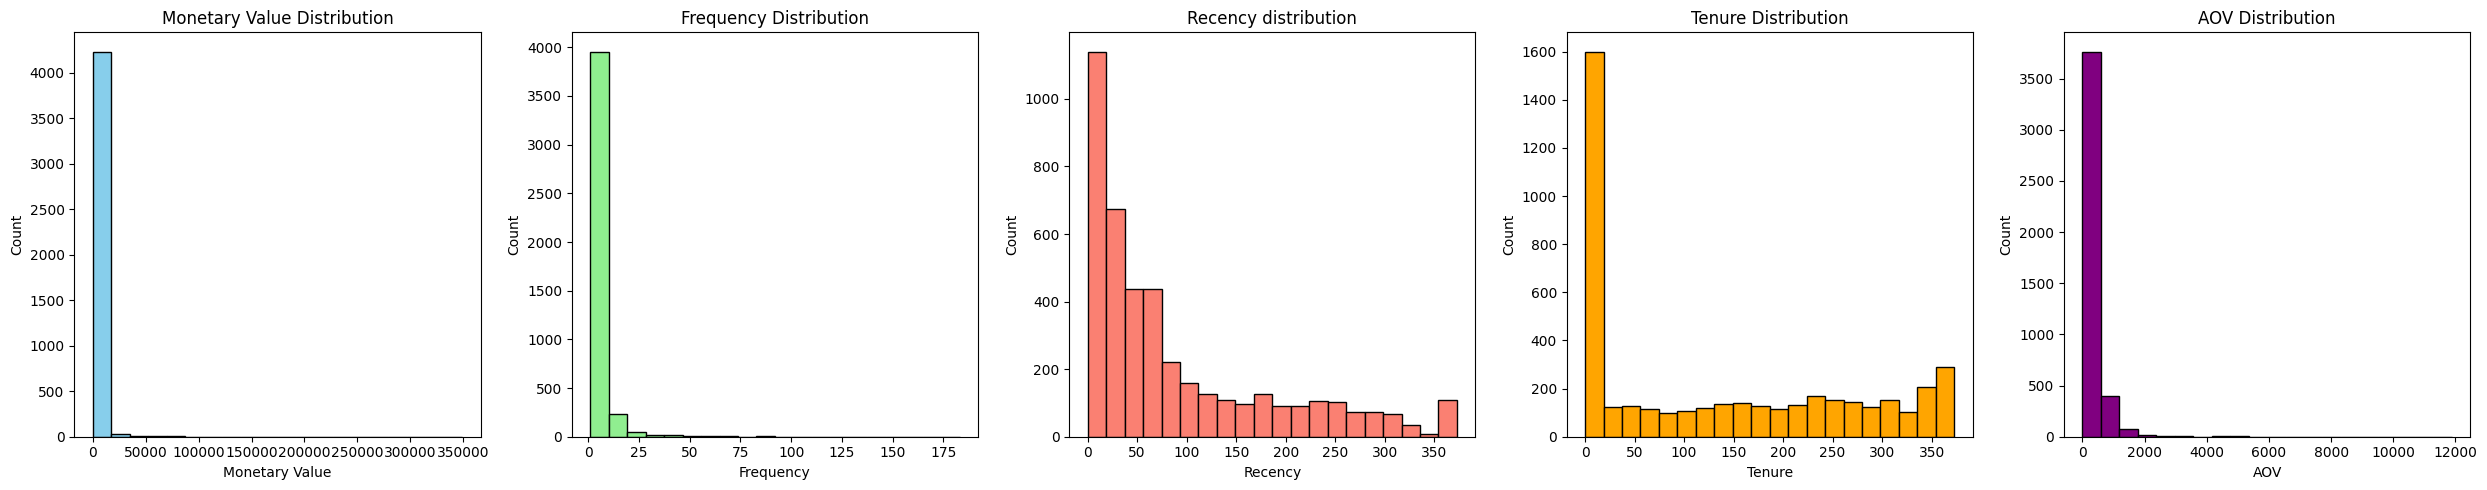

In [580]:
# shape/skewness visualization
plt.figure(figsize=(25, 5))

plt.subplot(1, 5, 1)
plt.hist(aggregated_df['MonetaryValue'], bins=20, color='skyblue', edgecolor='black')
plt.title('Monetary Value Distribution')
plt.xlabel('Monetary Value')
plt.ylabel('Count')

plt.subplot(1, 5, 2)
plt.hist(aggregated_df['Frequency'], bins=20, color='lightgreen', edgecolor='black')
plt.title('Frequency Distribution')
plt.xlabel('Frequency')
plt.ylabel('Count')

plt.subplot(1, 5, 3)
plt.hist(aggregated_df['Recency'], bins=20, color='salmon', edgecolor='black')
plt.title('Recency distribution')
plt.xlabel('Recency')
plt.ylabel('Count')

plt.subplot(1, 5, 4)
plt.hist(aggregated_df['Tenure'], bins=20, color='orange', edgecolor='black')
plt.title('Tenure Distribution')
plt.xlabel('Tenure')
plt.ylabel('Count')

plt.subplot(1, 5, 5)
plt.hist(aggregated_df['AOV'], bins=20, color='purple', edgecolor='black')
plt.title('AOV Distribution')
plt.xlabel('AOV')
plt.ylabel('Count')


plt.tight_layout()
plt.show()

ALL FEATURES ARE HEAVILY RIGHT-SKEWED

In [ ]:
print("D'Agostino-Pearson Normality Test")
print("H0: data is normally distributed")

for col in ["MonetaryValue", "Frequency", "Recency", "Tenure", "AOV"]:
    stat, p = normaltest(aggregated_df[col].dropna())
    result = "NON-NORMAL ✓" if p < 0.05 else "NORMAL"
    print(f"{col}: stat={stat:.2f}, p={p:.2e} → {result}")

D'Agostino-Pearson Normality Test
H0: data is normally distributed
p < 0.05 → reject H0 → non-normal → transformation required

MonetaryValue: stat=10265.06, p=0.00e+00 → NON-NORMAL ✓
Frequency: stat=6708.20, p=0.00e+00 → NON-NORMAL ✓
Recency: stat=780.45, p=3.36e-170 → NON-NORMAL ✓
Tenure: stat=104521.07, p=0.00e+00 → NON-NORMAL ✓
AOV: stat=7311.20, p=0.00e+00 → NON-NORMAL ✓


ALL FEATURES ARE CONFIRMED HIGHLY SKEWED BY STATISTICAL TEST (p < 0.05) — HIGH SKEWNESS DISTORTS EUCLIDEAN DISTANCES IN KMEANS → TRANSFORMATION IS REQUIRED

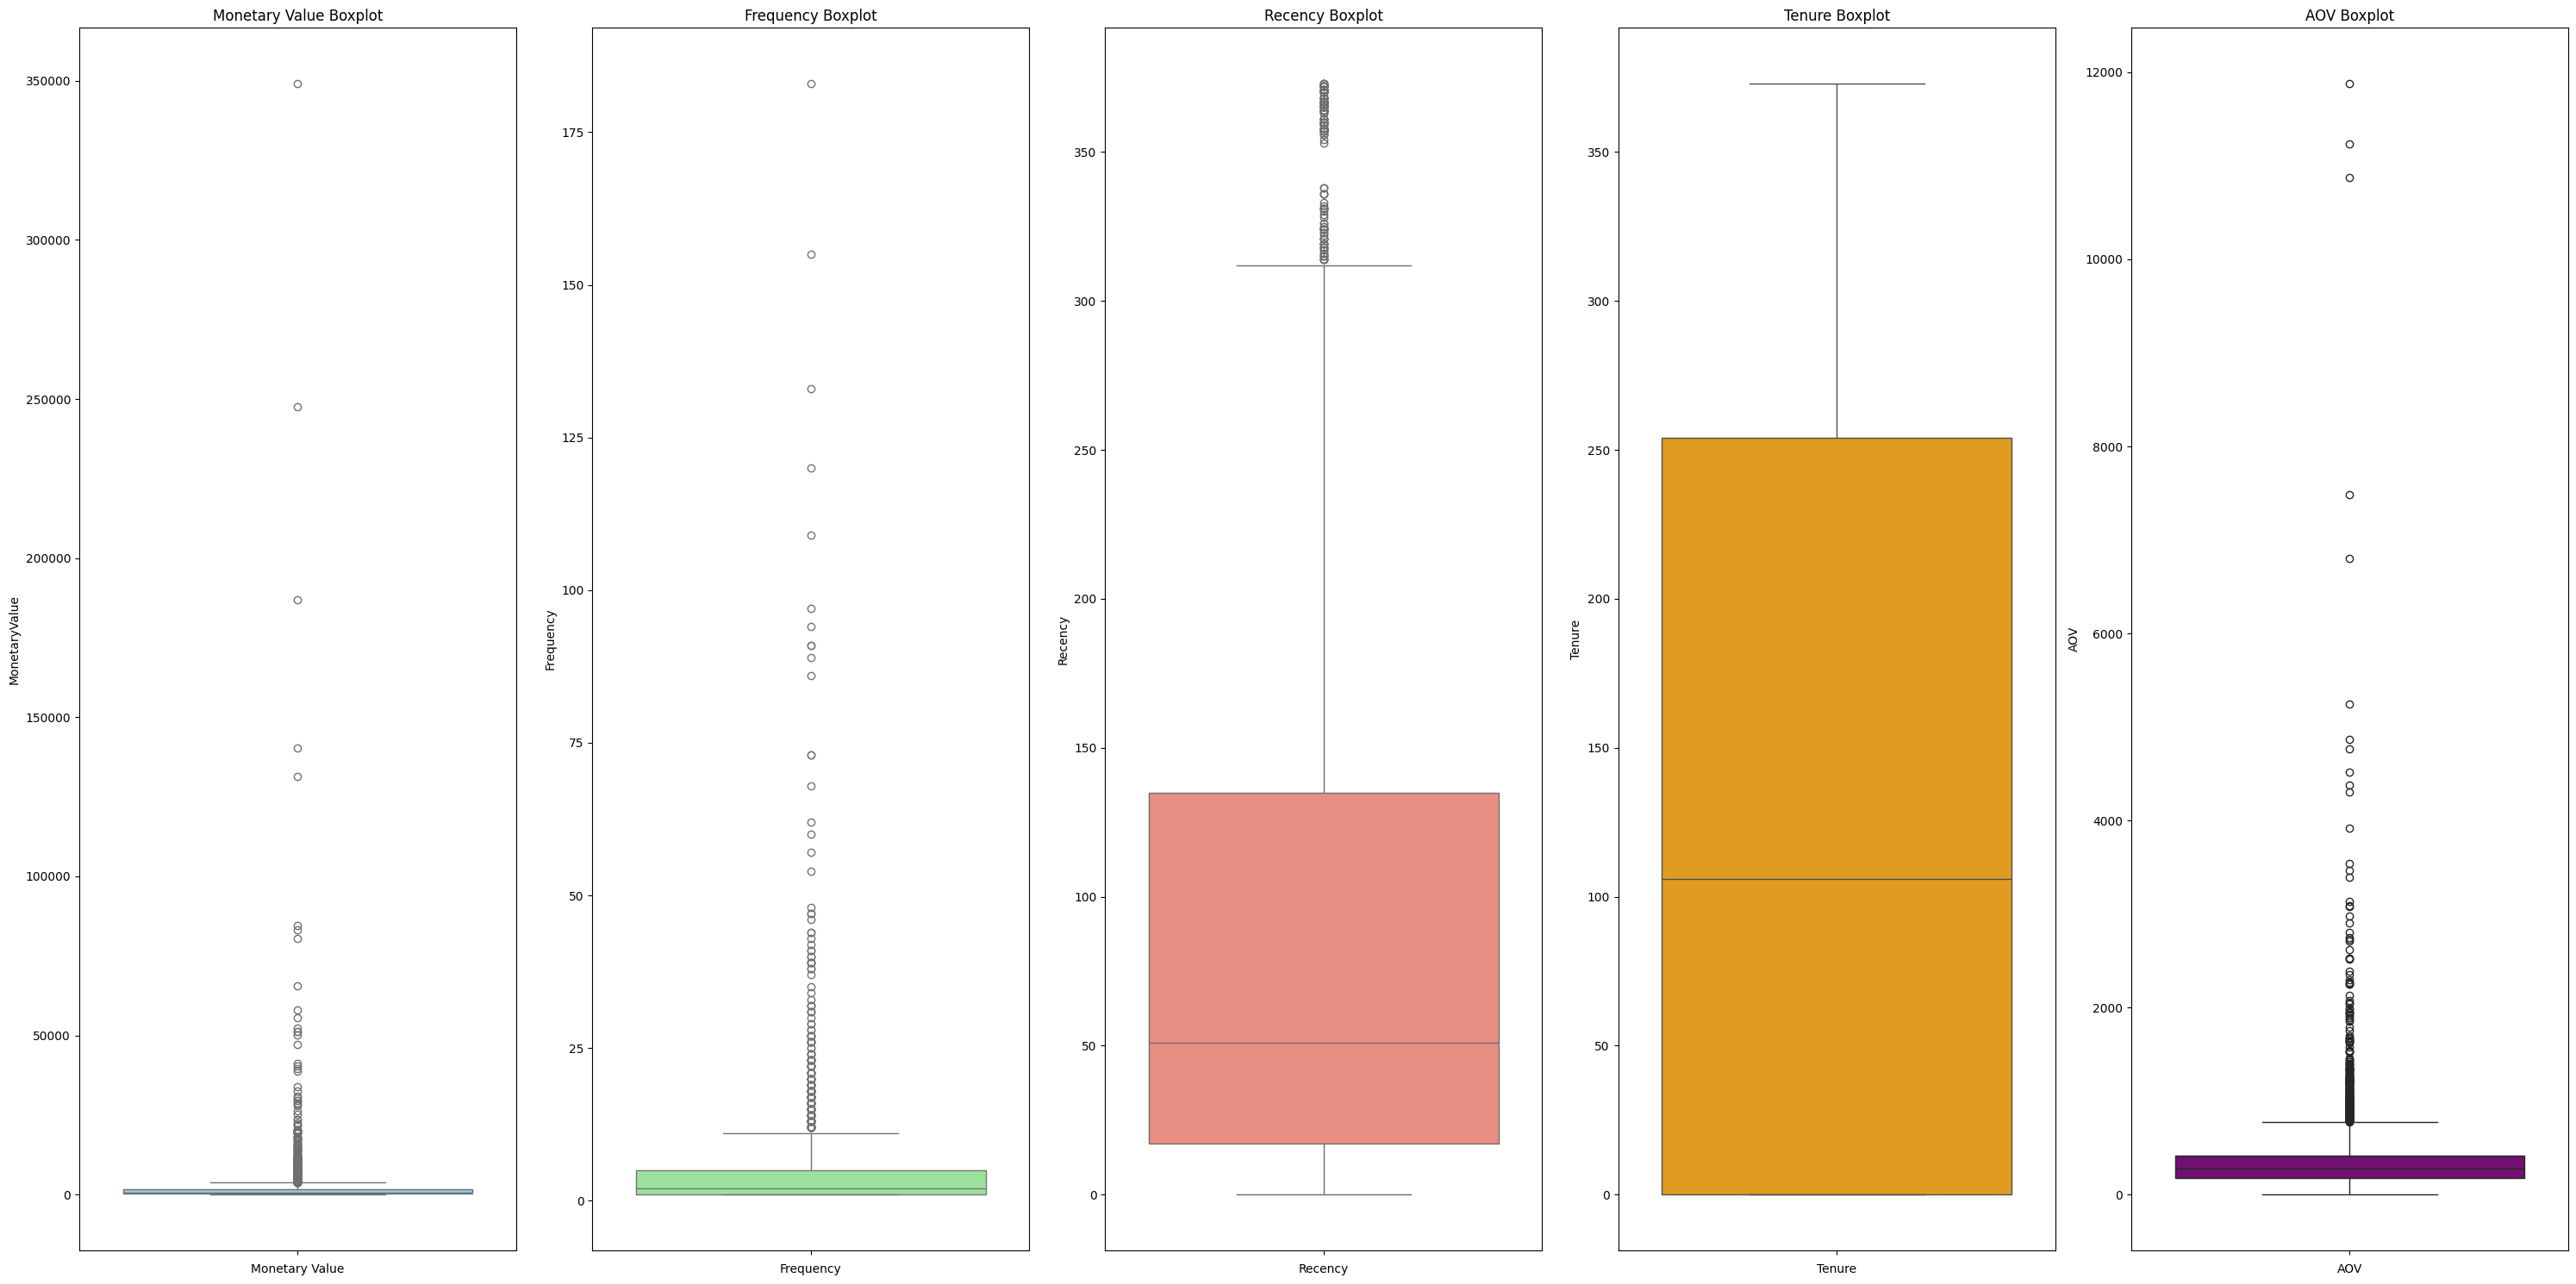

In [582]:
plt.figure(figsize=(30, 15))

plt.subplot(1, 5, 1)
sns.boxplot(data=aggregated_df['MonetaryValue'], color='skyblue')
plt.title('Monetary Value Boxplot')
plt.xlabel('Monetary Value')

plt.subplot(1, 5, 2)
sns.boxplot(data=aggregated_df['Frequency'], color='lightgreen')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

plt.subplot(1, 5, 3)
sns.boxplot(data=aggregated_df['Recency'], color='salmon')
plt.title('Recency Boxplot')
plt.xlabel('Recency')

plt.subplot(1, 5, 4)
sns.boxplot(data=aggregated_df['Tenure'], color='orange')
plt.title('Tenure Boxplot')
plt.xlabel('Tenure')

plt.subplot(1, 5, 5)
sns.boxplot(data=aggregated_df['AOV'], color='purple')
plt.title('AOV Boxplot')
plt.xlabel('AOV')

plt.tight_layout()
plt.show()


ALL FEATURES EXCEPT TENURE HAVE OUTLIERS, BUT TENURE ALSO HAS HIGH VARIANCE (SOME CUSTOMERS ARE BRAND NEW, SOME ARE VETERANS)

In [583]:
features = {
    "Recency": aggregated_df["Recency"],
    "MonetaryValue": aggregated_df["MonetaryValue"],
    "Frequency": aggregated_df["Frequency"],
    "Tenure": aggregated_df["Tenure"],
    "AOV": aggregated_df["AOV"],
}

for name, series in features.items():
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    mild_threshold = Q3 + 1.5 * IQR
    extreme_threshold = Q3 + 3.0 * IQR

    # All outliers
    outliers = aggregated_df[series > mild_threshold]

    # Mild only
    mild_outliers = aggregated_df[(series > mild_threshold) & (series <= extreme_threshold)]

    # Extreme
    extreme_outliers = aggregated_df[series > extreme_threshold]

    print(f"\n--- {name} ---")
    print(f"Total outliers (1.5×IQR): {len(outliers)}")
    print(f"Mild outliers: {len(mild_outliers)}")
    print(f"Extreme outliers: {len(extreme_outliers)}")

    if len(outliers) > 0:
        print(outliers[name].describe())


--- Recency ---
Total outliers (1.5×IQR): 167
Mild outliers: 167
Extreme outliers: 0
count   167.00
mean    350.97
std      20.51
min     314.00
25%     328.50
50%     360.00
75%     367.00
max     373.00
Name: Recency, dtype: float64

--- MonetaryValue ---
Total outliers (1.5×IQR): 421
Mild outliers: 192
Extreme outliers: 229
count      421.00
mean     12198.21
std      25886.95
min       3788.21
25%       4590.53
50%       6171.07
75%      10300.98
max     349164.35
Name: MonetaryValue, dtype: float64

--- Frequency ---
Total outliers (1.5×IQR): 279
Mild outliers: 151
Extreme outliers: 128
count   279.00
mean     23.81
std      21.93
min      12.00
25%      13.00
50%      17.00
75%      23.00
max     183.00
Name: Frequency, dtype: float64

--- Tenure ---
Total outliers (1.5×IQR): 0
Mild outliers: 0
Extreme outliers: 0

--- AOV ---
Total outliers (1.5×IQR): 294
Mild outliers: 164
Extreme outliers: 130
count     294.00
mean     1469.76
std      1335.44
min       781.65
25%       899.6

TENURE HAS NO OUTLIERS

FREQUENCY, MONETARY, AND AOV DO HAVE THEM

RECENCY HAS VERY MILD OUTLIERS — POWER TRANSFORMATION WILL DO THE JOB

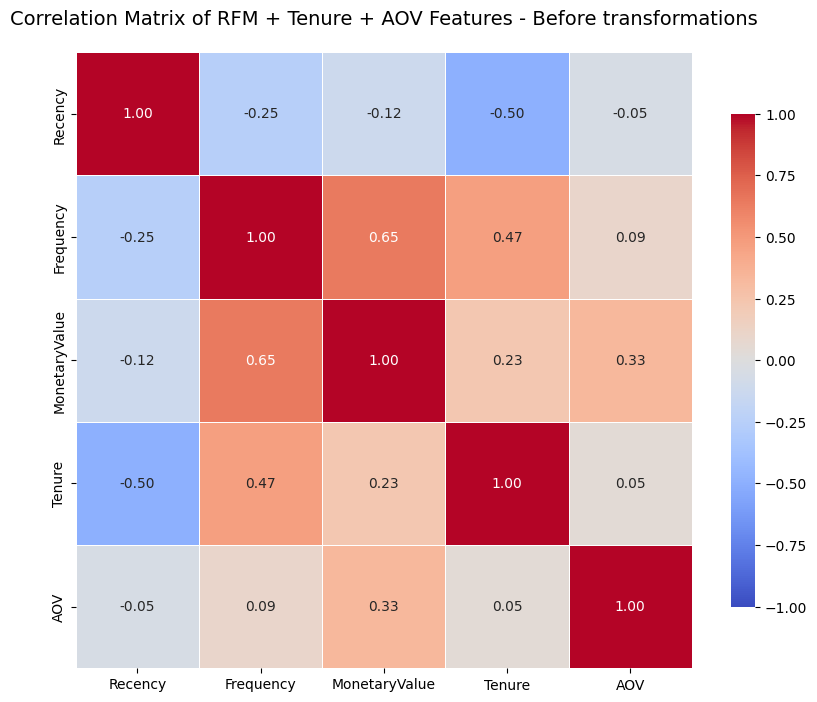

In [584]:
plt.figure(figsize=(10, 8))
corr = aggregated_df[['Recency', 'Frequency', 'MonetaryValue', 'Tenure', 'AOV']].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title("Correlation Matrix of RFM + Tenure + AOV Features - Before transformations", fontsize=14, pad=20)
plt.show()

NO STRONG MULTICOLINEARITY, ONLY MILD FOR FREQUENCY-MONETARY (0.65)

**CONCLUSIONS:** 

DATA IS HEAVILY RIGHT-SKEWED -  TRANSFORMATION IS NEEDED, 

MOST FEATURES HAVE SIGNIFICANT OUTLIERS - OUTLIER REMOVAL IS NEEDED, 

DATA IS ON DIFFERENT SCALES - NORMALIZATION IS NEEDED, 

MILD MULTICOLINEARITY FOR FREQUENCY-MONETARY, BUT IT'S BELOW 0.7 THRESHOLD, SO NO ACTION IS REQUIRED.

<h2 style="text-align: center">OUTLIER DETECTION AND REMOVAL</h2>

In [585]:
M_Q1 = aggregated_df["MonetaryValue"].quantile(0.25)
M_Q3 = aggregated_df["MonetaryValue"].quantile(0.75)
M_IQR = M_Q3 - M_Q1


monetary_outliers_df = aggregated_df[(aggregated_df["MonetaryValue"] > (M_Q3 + 1.5 * M_IQR)) | (aggregated_df["MonetaryValue"] < (M_Q1 - 1.5 * M_IQR))].copy()

monetary_outliers_df.describe()




,MonetaryValue,Frequency,Recency,Tenure,AOV
count,421.00,421.00,421.00,421.00,421.00
mean,12198.21,17.16,30.00,296.71,888.96
std,25886.95,19.77,51.61,89.33,1222.77
min,3788.21,1.00,0.00,0.00,144.94
25%,4590.53,8.00,3.00,259.00,389.72
50%,6171.07,12.00,13.00,338.00,546.30
75%,10300.98,18.00,31.00,359.00,917.36
max,349164.35,183.00,364.00,373.00,11880.84


In [586]:
F_Q1 = aggregated_df['Frequency'].quantile(0.25)
F_Q3 = aggregated_df['Frequency'].quantile(0.75)
F_IQR = F_Q3 - F_Q1


frequency_outliers_df = aggregated_df[(aggregated_df['Frequency'] > (F_Q3 + 1.5 * F_IQR)) 
                                      | (aggregated_df['Frequency'] < (F_Q1 - 1.5 * F_IQR))].copy()

frequency_outliers_df.describe()



,MonetaryValue,Frequency,Recency,Tenure,AOV
count,279.00,279.00,279.00,279.00,279.00
mean,14374.12,23.81,16.09,327.47,506.77
std,31383.98,21.93,26.59,55.15,478.30
min,1091.44,12.00,0.00,77.00,27.38
25%,4328.43,13.00,2.00,311.50,264.95
50%,6615.77,17.00,7.00,352.00,368.85
75%,11652.41,23.00,19.00,363.00,535.78
max,349164.35,183.00,211.00,373.00,3923.19


In [587]:
AOV_Q1 = aggregated_df['AOV'].quantile(0.25)
AOV_Q3 = aggregated_df['AOV'].quantile(0.75)
AOV_IQR = AOV_Q3 - AOV_Q1

aov_outliers_df = aggregated_df[(aggregated_df['AOV'] > (AOV_Q3 + 1.5 * AOV_IQR)) 
                                | (aggregated_df['AOV'] < (AOV_Q1 - 1.5 * AOV_IQR))].copy()

aov_outliers_df.describe()

,MonetaryValue,Frequency,Recency,Tenure,AOV
count,294.00,294.00,294.00,294.00,294.00
mean,10269.23,6.59,77.80,145.44,1469.76
std,29824.06,12.83,83.15,135.77,1335.44
min,787.20,1.00,0.00,0.00,781.65
25%,1652.12,1.00,18.00,0.00,899.62
50%,3269.45,3.00,52.00,126.00,1071.80
75%,7236.68,6.00,98.00,275.00,1398.02
max,349164.35,94.00,366.00,373.00,11880.84


In [588]:
non_outliers_df = aggregated_df[
    (~aggregated_df.index.isin(monetary_outliers_df.index)) & 
    (~aggregated_df.index.isin(frequency_outliers_df.index)) &
    (~aggregated_df.index.isin(aov_outliers_df.index))].copy()
non_outliers_df.describe()

,MonetaryValue,Frequency,Recency,Tenure,AOV
count,3649.00,3649.00,3649.00,3649.00,3649.00
mean,836.46,2.92,97.10,116.29,281.14
std,784.60,2.27,98.66,124.03,151.55
min,1.55,1.00,0.00,0.00,1.55
25%,263.73,1.00,22.00,0.00,167.16
50%,546.34,2.00,57.00,73.00,257.04
75%,1190.82,4.00,154.00,225.00,358.15
max,3786.70,11.00,373.00,373.00,780.23


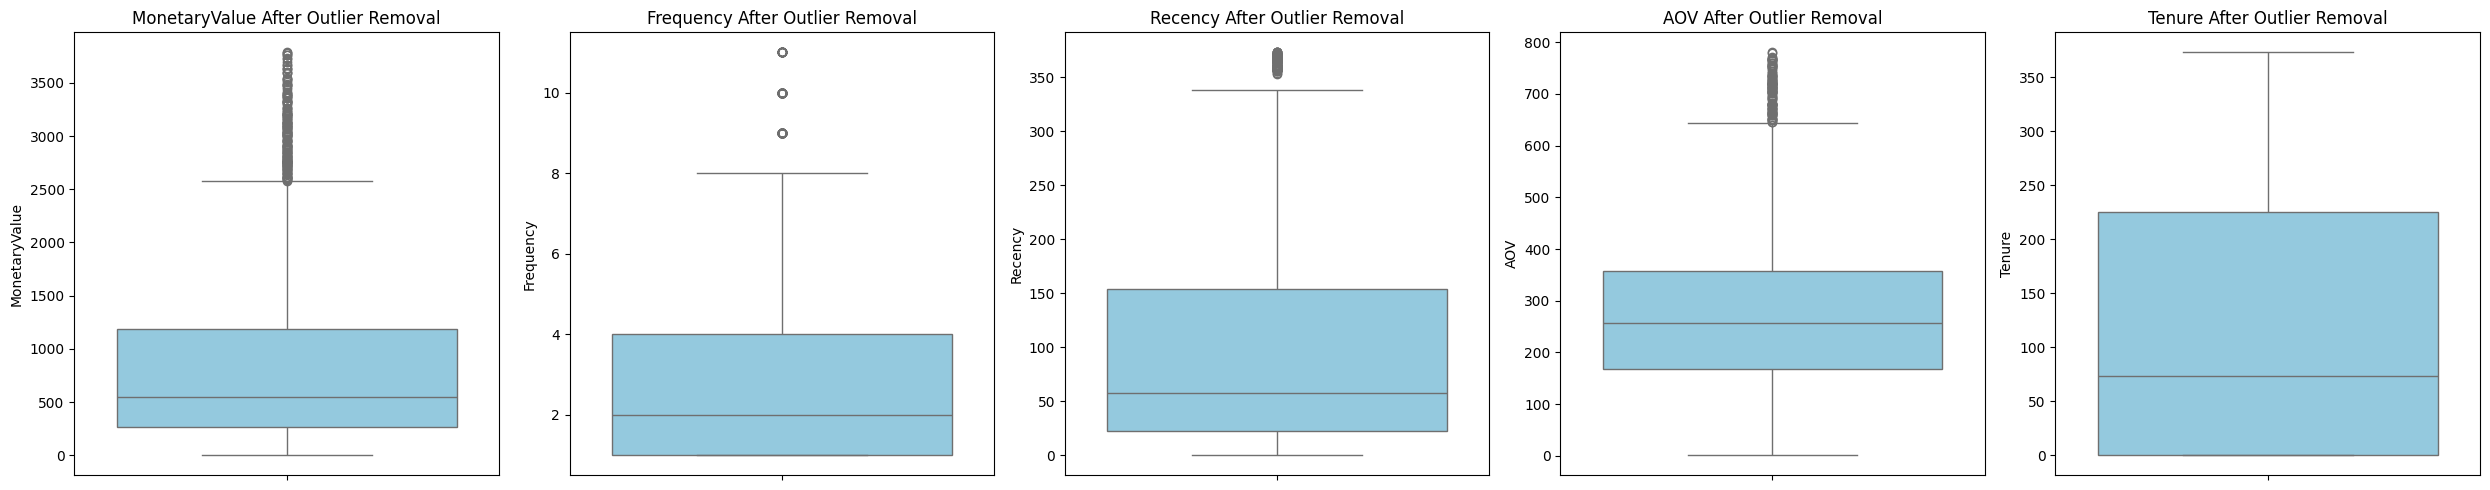

In [589]:
plt.figure(figsize=(25, 5))

for i, col in enumerate(["MonetaryValue", "Frequency", "Recency", "AOV", "Tenure"], 1):
    plt.subplot(1, 5, i)
    sns.boxplot(data=non_outliers_df[col], color='skyblue')
    plt.title(f'{col} After Outlier Removal')

plt.tight_layout()
plt.show()

**CONCLUSION:** THE NUMBER OF OUTLIERS HAS DECREASED, THE REMAINING OUTLIERS  - POWER TRANSFORMATION SHOULD HANDLE BY COMPRESSING EXTREME VALUES TOWARD THE CENTER SO IT WILL NOT DISTORT THE ALGORITHM

**POWER TRANSFORMATION:** 

In [590]:
cols = ["MonetaryValue", "Frequency", "Recency", "Tenure", "AOV"]
pt = PowerTransformer(method='yeo-johnson')
transformed_df = non_outliers_df[cols].copy()
transformed_df[cols] = pt.fit_transform(non_outliers_df[cols])

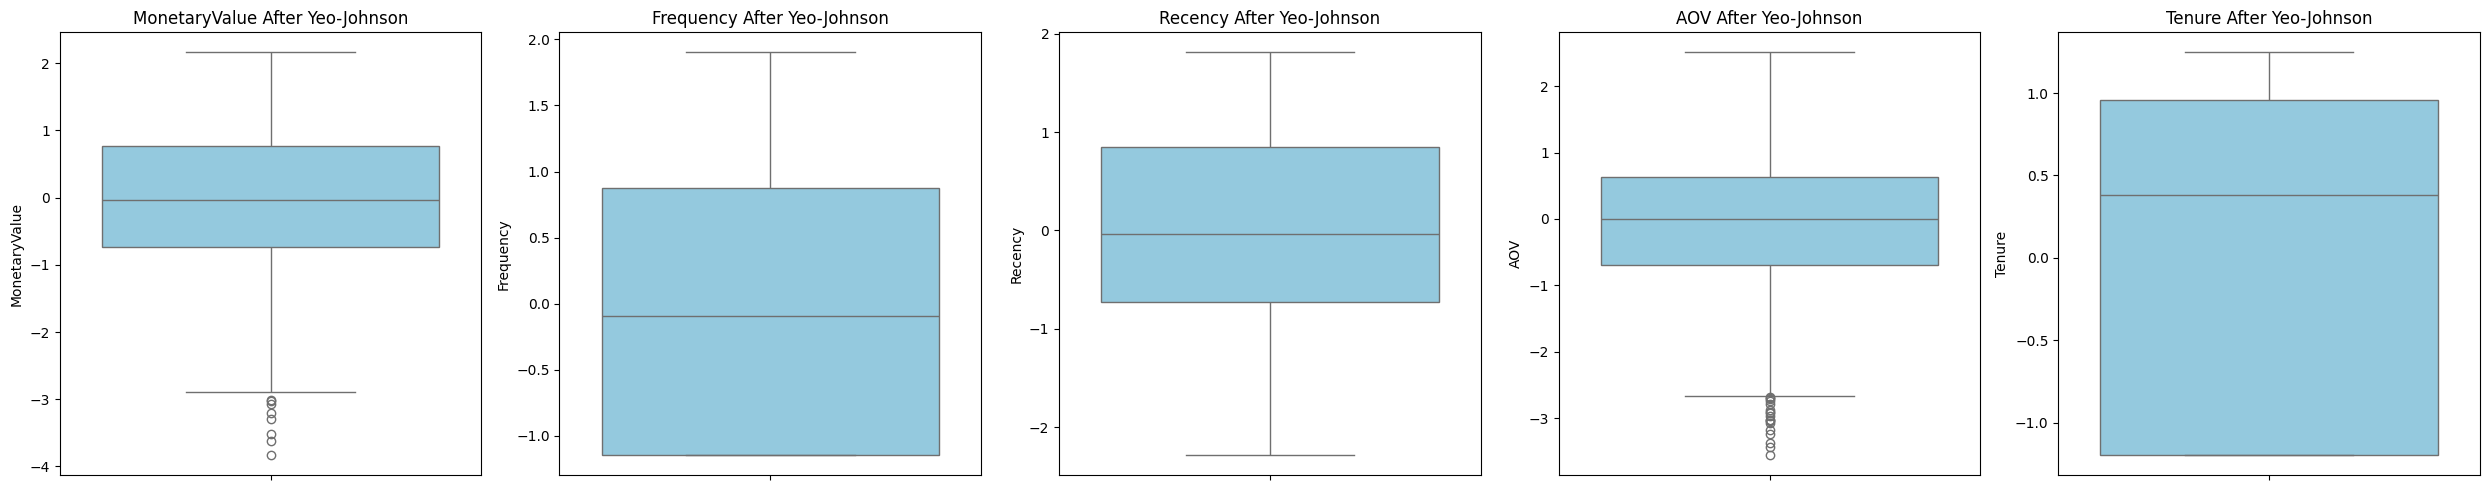

In [591]:
plt.figure(figsize=(25, 5))

for i, col in enumerate(["MonetaryValue", "Frequency", "Recency", "AOV", "Tenure"], 1):
    plt.subplot(1, 5, i)
    sns.boxplot(data=transformed_df[col], color='skyblue')
    plt.title(f'{col} After Yeo-Johnson')

plt.tight_layout()
plt.show()

IT WORKED, BUT SLIGHT MONETARY AND AOV OUTLIERS STILL REMAINED (MAINLY LOWER SIDES)

In [592]:
for col in ["MonetaryValue", "Frequency", "Recency", "AOV"]:
    z_scores = np.abs(stats.zscore(transformed_df[col]))
    print(f"{col}: {(z_scores > 3).sum()} outliers")

MonetaryValue: 8 outliers
Frequency: 0 outliers
Recency: 0 outliers
AOV: 9 outliers


INSIGNIFICANT NUMBER OF OUTLIERS HAVE LEFT

In [593]:
for col in ["MonetaryValue", "AOV"]:
    z_scores = np.abs(stats.zscore(transformed_df[col]))
    print(f"\n{col}:")
    print(transformed_df[col][z_scores > 3].describe())


MonetaryValue:
count    8.00
mean    -3.32
std      0.30
min     -3.83
25%     -3.54
50%     -3.25
75%     -3.06
max     -3.01
Name: MonetaryValue, dtype: float64

AOV:
count    9.00
mean    -3.22
std      0.20
min     -3.56
25%     -3.38
50%     -3.17
75%     -3.04
max     -3.02
Name: AOV, dtype: float64


**CONCLUSION:** 

THESE POINTS WILL NOT PULL THE CENTROID SIGNIFICANTLY

THEY REPRESENT VERY FEW LOW-SPENDING CUSTOMERS → MEANINGFUL CLUSTER

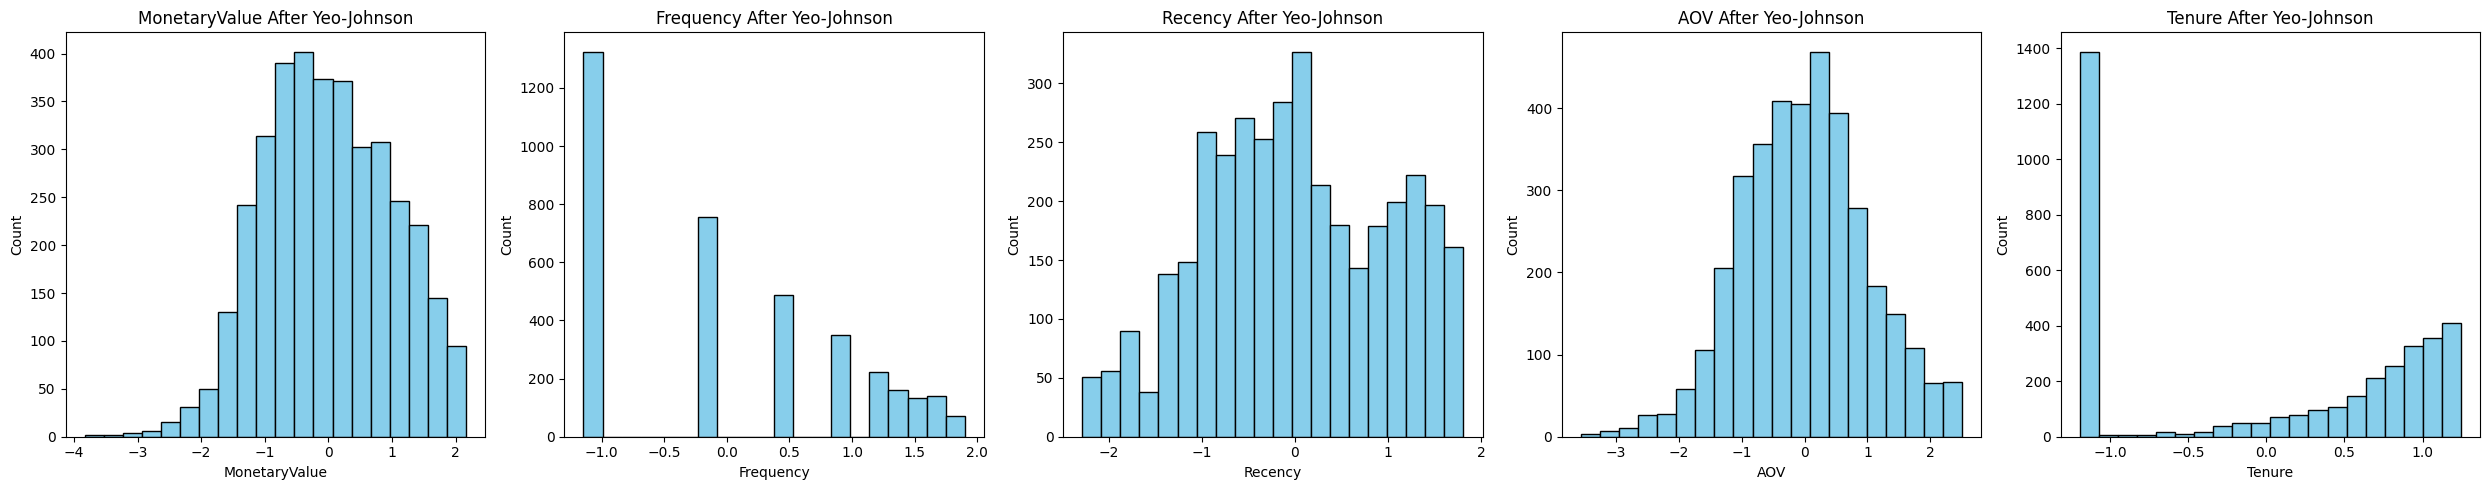

In [594]:
plt.figure(figsize=(25, 5))

for i, col in enumerate(["MonetaryValue", "Frequency", "Recency", "AOV", "Tenure"], 1):
    plt.subplot(1, 5, i)
    plt.hist(transformed_df[col], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'{col} After Yeo-Johnson')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

MONETARY AND AOV ROUGHLY NORMALLY DISTRIBUTED,

RECENCY IS ROUGHLY UNIFORM WITH A SLIGHT PEAK NEAR 0 — YEO-JOHNSON FLATTENED THE ORIGINAL RIGHT SKEW WELL

FREQUENCY HAS HIGHER RIGHT SKEW (MOST CUSTOMERS BUY FEW TIMES, FEW BUY MANY)

TENURE HAS THOUSANDS OF CUSTOMERS WITH EXACTLY 0 DAYS (SAME-DAY BUYERS) WHICH YEO-JOHNSON MAPS TO -1.0

In [595]:
non_outliers_df["Frequency"].value_counts().head(10)

Frequency
1     1325
2      755
3      489
4      351
5      222
6      162
7      133
8       83
9       56
10      50
Name: count, dtype: int64

FREQUENCY ADDITIONALLY IS A GRADUAL DECAY - NATURAL CUSTOMER BEHAVIOR, WHERE MOST BUY INFREQUENTLY, LESS IMPACTFUL FOR CLUSTERS

In [596]:
non_outliers_df["Tenure"].value_counts().head(10)

Tenure
0      1388
230      14
356      13
241      13
336      13
301      13
350      13
276      12
354      12
74       12
Name: count, dtype: int64

TENURE HAS A MASSIVE SPIKE AT 0 DAYS (~1388 CUSTOMERS).

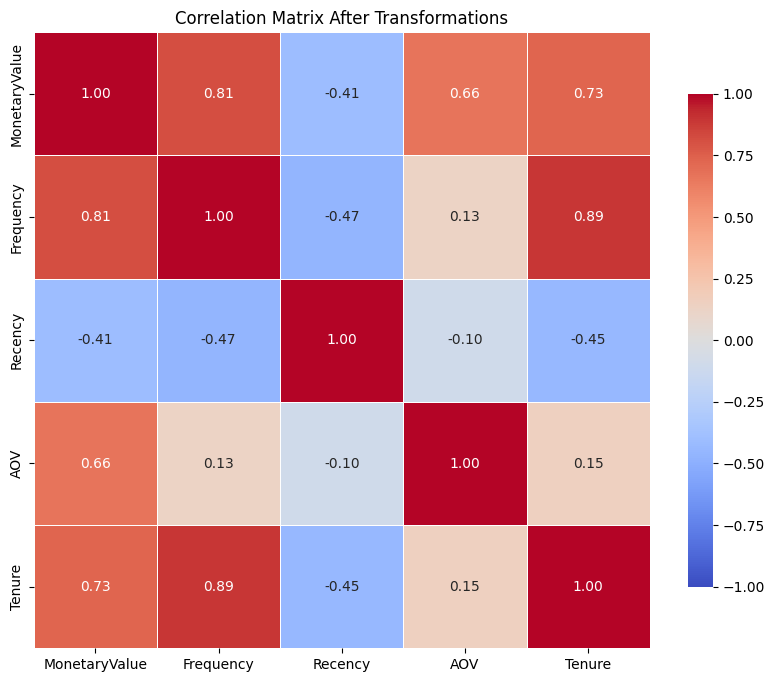

In [597]:
plt.figure(figsize=(10, 8))
corr = transformed_df[["MonetaryValue", "Frequency", "Recency", "AOV", "Tenure"]].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title("Correlation Matrix After Transformations")
plt.show()

ANOTHER REASON TO DROP TENURE - TENURE IS HIGHLY CORRELATED WITH FREQUENCY (0.89) AND MONETARYVALUE (0.73) — IT'S REDUNDANT, ADDS MULTICOLLINEARITY, AND SHOULD BE DROPPED BEFORE CLUSTERING.

In [598]:
transformed_df.drop(columns=["Tenure"], inplace=True)

transformed_df

,MonetaryValue,Frequency,Recency,AOV
0,-1.12,-0.09,0.91,-1.56
1,0.89,-0.09,-1.85,2.05
2,-0.89,-1.14,0.17,-0.26
4,-0.61,-1.14,-1.19,0.28
5,-0.49,-0.09,-1.19,-0.66
...,...,...,...,...
4280,0.08,1.34,-0.88,-1.33
4281,-0.32,-1.14,0.08,0.92
4282,-0.40,-1.14,1.54,0.73
4283,0.83,-0.09,0.54,1.90


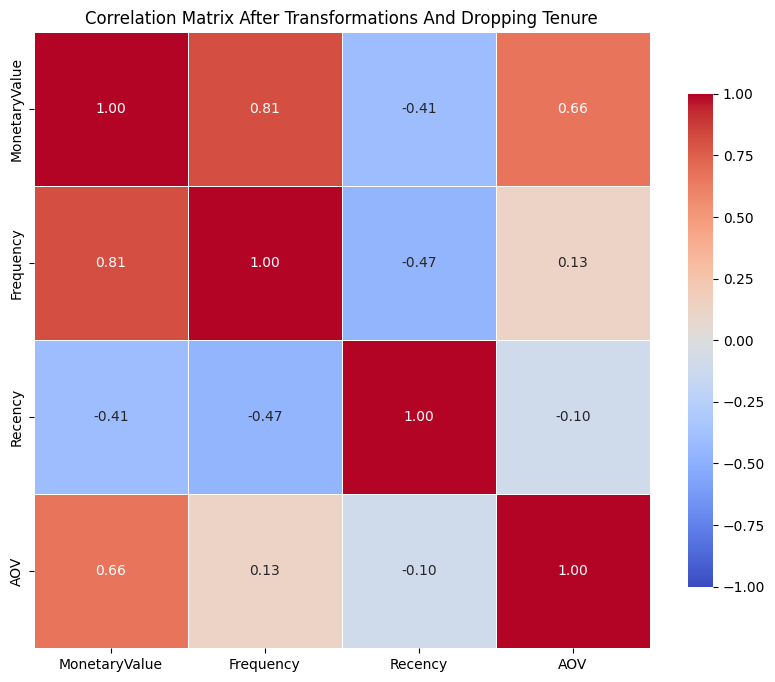

In [599]:
plt.figure(figsize=(10, 8))
corr = transformed_df[["MonetaryValue", "Frequency", "Recency", "AOV"]].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title("Correlation Matrix After Transformations And Dropping Tenure")
plt.show()

MONETARYVALUE ↔ FREQUENCY: 0.81 — VERY HIGH, CUSTOMERS WHO BUY OFTEN ALSO SPEND MORE. THIS MULTICOLLINEARITY WILL BE HANDLED BY PCA, WHICH DECORRELATES FEATURES BEFORE FEEDING INTO KMEANS.

MONETARYVALUE ↔ AOV: 0.66 — MODERATE, EXPECTED.

RECENCY ↔ FREQUENCY: -0.47 AND RECENCY ↔ MONETARYVALUE: -0.41 — MAKES SENSE, INACTIVE CUSTOMERS BUY LESS AND SPEND LESS.

AOV ↔ FREQUENCY: 0.13 AND AOV ↔ RECENCY: -0.09 — AOV IS NEARLY INDEPENDENT - ADDS UNIQUE INFORMATION.

In [600]:
pca_check = PCA()
pca_check.fit(transformed_df)
print(np.cumsum(pca_check.explained_variance_ratio_))

[0.59346989 0.8496605  0.9979089  1.        ]


3 COMPONENTS EXPLAIN ALMOST 100% OF THE DATA

In [601]:
pca = PCA(n_components=3)
pca_data = pca.fit_transform(transformed_df)

loadings = pd.DataFrame(
    pca.components_,
    columns=transformed_df.columns,
    index=['PC1', 'PC2', 'PC3']
)
print(loadings)
print(f"\nExplained variance ratio: {pca.explained_variance_ratio_}")

     MonetaryValue  Frequency  Recency   AOV
PC1           0.63       0.54    -0.40  0.38
PC2           0.17      -0.35     0.53  0.76
PC3           0.21       0.54     0.75 -0.32

Explained variance ratio: [0.59346989 0.25619061 0.1482484 ]


<h2 style="text-align: center">K-MEANS CLUSTERING</h2>

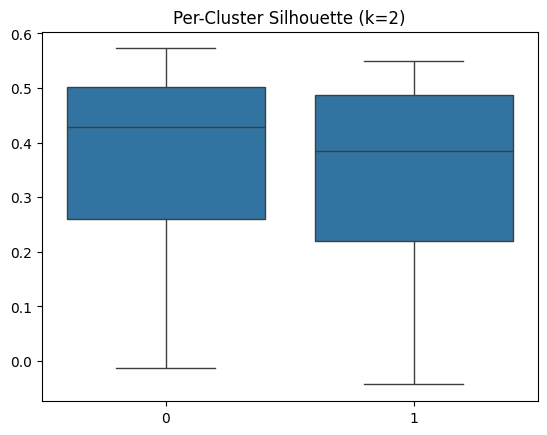

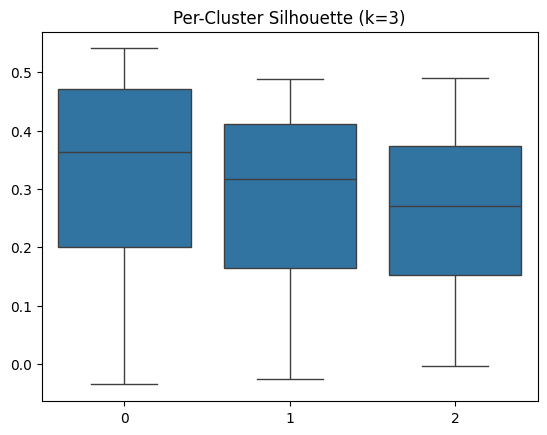

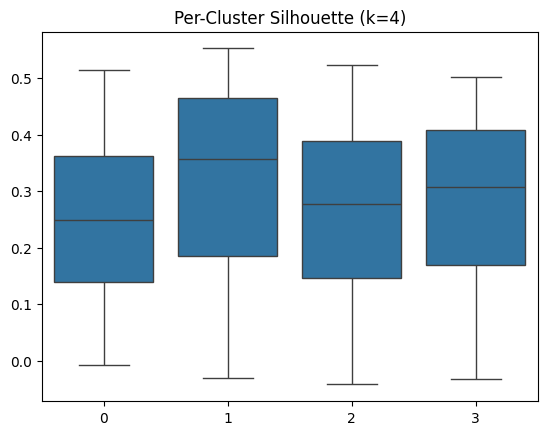

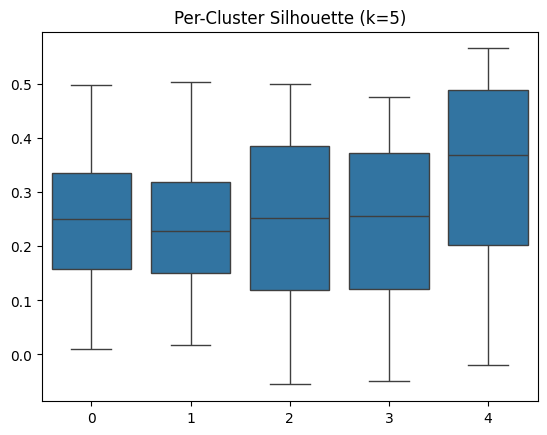

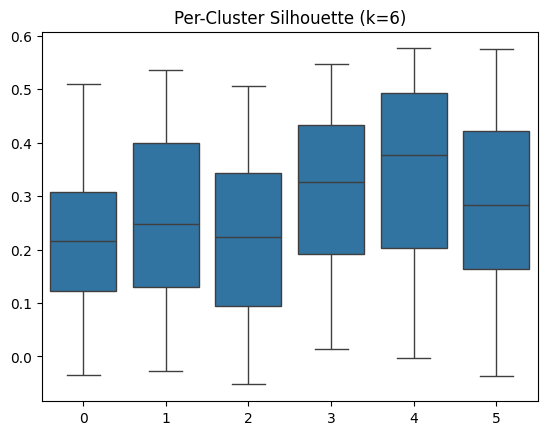

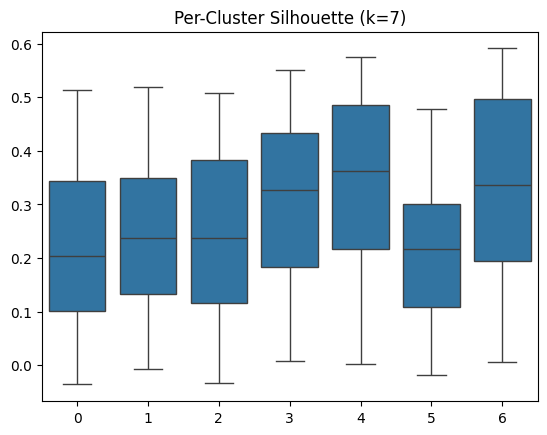

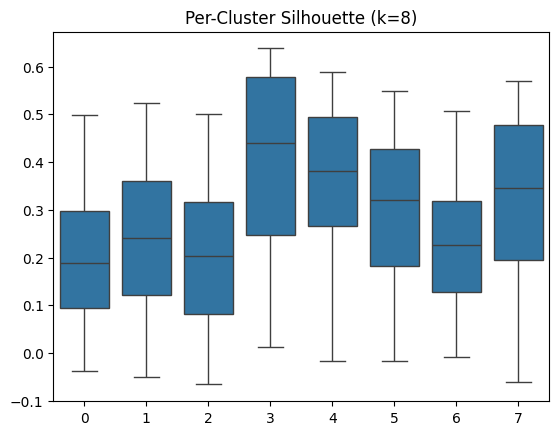

In [602]:
max_k = 8
inertia = []
silhouette_scores = []
k_values = range(2, max_k + 1)

for k in k_values:

    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=300)
    cluster_labels = kmeans.fit_predict(pca_data)
    sil_score = silhouette_score(pca_data, cluster_labels)
    silhouette_scores.append(sil_score)
    inertia.append(kmeans.inertia_)

    sample_sil_values = silhouette_samples(pca_data, cluster_labels)
    sns.boxplot(x=cluster_labels, y=sample_sil_values)
    plt.title(f"Per-Cluster Silhouette (k={k})")
    plt.show()

K=2 AND K=3 SCORE HIGHER BUT ARE TOO COARSE FOR MEANINGFUL BUSINESS SEGMENTATION

K=4 ALL 4 CLUSTERS HAVE CONSISTENTLY REASONABLE SILHOUETTE SCORES (~0.25–0.5) WITH NO WEAK CLUSTERS

K=5 CLUSTERS ARE STILL CONSISTENT BUT OFFER NO BUSINESS IMPROVEMENT OVER K=4

K=6 AND K=7 SHOW INCREASINGLY UNEVEN CLUSTERS — SOME BOXES ARE HIGH (~0.5) WHILE OTHERS DROP TO ~0.2, MEANING CERTAIN CLUSTERS ARE POORLY SEPARATED

K=8 HAS CLUSTERS WITH SLIGHTLY NEGATIVE SILHOUETTE VALUES (~-0.1) — SOME CUSTOMERS ARE CLOSER TO A NEIGHBORING CLUSTER THAN THEIR OWN, WHICH IS A SIGN OF OVER-CLUSTERING

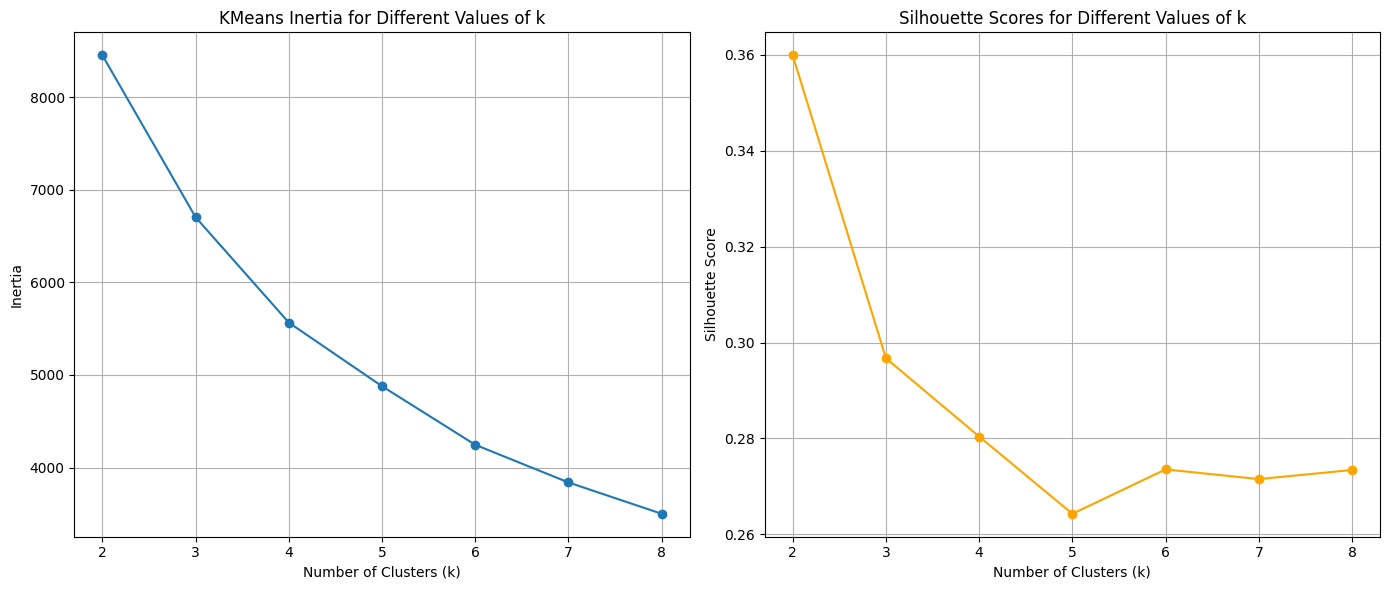

In [603]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(k_values, inertia, marker='o')
plt.title('KMeans Inertia for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Scores for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()

INERTIA: NO CLEAR ELBOW, SLOWS SLIGHTLY AFTER K=5-6

SILHOUETTE: SHARP DECLINE FROM K=2, HITS LOWEST AT K=5, THEN STABILIZES

BASED ON PER-CLUSTER SILHOUETTE, INERTIA AND SILHOUETTE SCORE ABOVE, THE MOST OPTIMAL FROM STATISTICAL POINT OF VIEW THE NUMBER OF CLUSTERS IS 2, BUT HIGLY IMPRACTICAL SO 3 BECOMES REALISTIC, BUT 3 IS ALSO LIMITED FROM THE BUSINESS PERSPECTIVE — NEEDS LATER EXAMINATION WHETHER 3 OR 4, BECAUSE 5 HITS THE LOWEST

In [604]:
seeds = [42, 0, 7, 123, 999]

for k in [2, 3, 4, 5, 6, 7, 8]:
    scores = []
    for seed in seeds:
        km = KMeans(n_clusters=k, random_state=seed, max_iter=300, n_init=50)
        labels = km.fit_predict(pca_data)
        scores.append(silhouette_score(pca_data, labels))
    print(f"k={k}: mean={np.mean(scores):.4f}, std={np.std(scores):.4f}")

k=2: mean=0.3598, std=0.0000
k=3: mean=0.2972, std=0.0002
k=4: mean=0.2809, std=0.0000
k=5: mean=0.2661, std=0.0000
k=6: mean=0.2763, std=0.0001
k=7: mean=0.2721, std=0.0001
k=8: mean=0.2712, std=0.0006


ALL VALUES (0.27–0.36) FALL IN THE WEAK RANGE STANDARD. NONE CROSS THE 0.5 THRESHOLD. FOR CUSTOMER SEGMENTATION ON REAL-WORLD RFM DATA, 0.27–0.36 IS WIDELY ACCEPTED. CUSTOMER BEHAVIOR IS INHERENTLY CONTINUOUS — PEOPLE DON'T FALL INTO NEAT DISCRETE GROUPS.

K=5 K=6, K=7, K=8 ARE THE LOWEST, 
 
K2 IS THE STRONGEST BUT AGAIN FROM THE BUSINESS PERSPECTIVE USELESS, 
 
NEXT IS K=3, POTENTIAL CANDIDATE
 
NEXT AFTER K=3 IS K=4

NEEDS FURTHER BUSINESS EXAMINATION WHETHER 3 OR 4

In [605]:
base = KMeans(n_clusters=4, random_state=42, n_init=50).fit_predict(pca_data)

for seed in [0, 7, 123, 999]:
    labels = KMeans(n_clusters=4, random_state=seed, n_init=50).fit_predict(pca_data)
    print(f"seed={seed}: ARI={adjusted_rand_score(base, labels):.4f}")

seed=0: ARI=0.9978
seed=7: ARI=0.9978
seed=123: ARI=0.9978
seed=999: ARI=0.9978


CLUSTER ASSIGNMENTS ARE PERFECTLY STABLE ACROSS ALL SEEDS (ARI ≈ 0.9978).
n_init=50 ENSURES THE ALGORITHM ESCAPES LOCAL OPTIMA CONSISTENTLY.
THE MODEL IS ROBUST AND DETERMINISTIC IN PRACTICE.

In [606]:
kmeans = KMeans(n_clusters=4, random_state=42, max_iter=300, n_init=50)
cluster_labels = kmeans.fit_predict(pca_data)
cluster_labels

array([0, 2, 0, ..., 3, 3, 2], shape=(3649,), dtype=int32)

In [607]:
non_outliers_df["Cluster"] = cluster_labels
non_outliers_df

,Customer ID,MonetaryValue,Frequency,Recency,Tenure,AOV,Cluster
0,12346,169.36,2,164,118,84.68,0
1,12347,1323.32,2,2,37,661.66,2
2,12348,221.16,1,73,0,221.16,0
4,12351,300.93,1,10,0,300.93,3
5,12352,343.80,2,10,16,171.90,1
...,...,...,...,...,...,...,...
4280,18283,619.37,6,17,275,103.23,1
4281,18284,411.68,1,66,0,411.68,3
4282,18285,377.00,1,295,0,377.00,3
4283,18286,1246.43,2,111,247,623.22,3


In [608]:
print(non_outliers_df.groupby("Cluster")[["MonetaryValue", "Frequency", "Recency", "AOV"]].mean())

         MonetaryValue  Frequency  Recency    AOV
Cluster                                          
0               165.43       1.23   164.90 139.94
1               595.60       3.22    46.15 197.72
2              1885.70       5.45    40.54 376.44
3               544.24       1.37   144.78 398.70


**QUICK SUMMARY OF THE RESULTS ABOVE**:

CLUSTER 0 — LOW SPEND, LOW FREQUENCY, HIGH RECENCY, LOW AOV → CHURNED (INACTIVE, RARE, LOW VALUE)

CLUSTER 1 — HIGH SPEND, HIGH FREQUENCY, MOST RECENT, HIGH AOV → VIP (BEST CUSTOMERS, ACTIVE, FREQUENT, HIGH VALUE)

CLUSTER 2 — MID SPEND, LOW FREQUENCY, HIGH RECENCY, HIGH AOV — THESE CUSTOMERS BUY RARELY BUT SPEND WELL PER ORDER WHEN THEY DO. THEY'RE NOT CHURNED YET BUT DISENGAGED. RISK OF LOSING THEM → AT-RISK HIGH-VALUE

CLUSTER 3 — MID SPEND, MID-HIGH FREQUENCY, LOW RECENCY, LOW AOV → LOYAL (FREQUENT AND RECENT BUT LOWER SPEND PER ORDER)

In [609]:
for k in [3]:
    km = KMeans(n_clusters=k, random_state=42, max_iter=300, n_init=50)
    labels = km.fit_predict(pca_data)
    raw_with_k3 = aggregated_df.loc[non_outliers_df.index].copy()
    raw_with_k3["Cluster"] = labels
    print(raw_with_k3.groupby("Cluster")[["MonetaryValue", "Frequency", "Recency", "AOV"]].mean())

         MonetaryValue  Frequency  Recency    AOV
Cluster                                          
0               201.10       1.48   139.49 143.18
1              1493.57       4.94    37.65 313.86
2               575.63       1.52   137.81 388.53


K=3 WOULD MERGE LOYAL AND AT-RISK HIGH-VALUE. DESPITE SIMILAR MONETARY VALUE, THEY DIFFER CRITICALLY:
AOV: £399 VS £199 — AT-RISK SPENDS 2X PER ORDER
RECENCY: 145 VS 47 DAYS — AT-RISK IS DISENGAGED, LOYAL IS STILL ACTIVE
MERGING THEM WOULD DILUTE BOTH SIGNALS AND LEAD TO WRONG MARKETING STRATEGY — AT-RISK NEEDS AGGRESSIVE WIN-BACK, LOYAL NEEDS UPSELLING. K=4 PRESERVES THIS DISTINCTION.

**CONCLUSION**: 

K=4 SEEMS THE OPTIMAL CHOICE BETWEEN BUSINESS GOALS AND STATISTICAL SCORE, ALTHOUGH K=3 IS STATISTICALLY STRONGER, IT WOULD MERGE DISTINCTFUL CLUSTERS WHICH FROM THE BUSINESS POINT OF VIEW WOULD BE CATASTROPHICAL, ADDITIONALY TO THAT, K=4 IS NOT STATISTICALLY WEAK LIKE K=5, SO IT IS THE MOST OPTIMAL CHOICE.

In [610]:
cluster_means = non_outliers_df.groupby("Cluster")[["MonetaryValue", "Frequency", "Recency", "AOV"]].mean()

vip_cluster = cluster_means["MonetaryValue"].idxmax()
churned_cluster = cluster_means["Recency"].idxmax()
remaining = cluster_means.drop([vip_cluster, churned_cluster])
atrisk_cluster = remaining["AOV"].idxmax()
loyal_cluster = [c for c in cluster_means.index if c not in [vip_cluster, churned_cluster, atrisk_cluster]][0]

cluster_labels_names = {
    vip_cluster: "VIP",
    churned_cluster: "Churned",
    atrisk_cluster: "At-Risk High-Value",
    loyal_cluster: "Loyal"
}

cluster_colors = {
    'VIP': '#ff7f0e',
    'Churned': '#1f77b4',
    'At-Risk High-Value': '#2ca02c',
    'Loyal': '#d62728'
}

In [611]:
for name, cutoff in [("H1", "2010-07-01"), ("H2", "2010-12-09")]:
    subset = cleaned_df[cleaned_df["InvoiceDate"] < cutoff] if name == "H1" else cleaned_df[cleaned_df["InvoiceDate"] >= "2010-07-01"]
    subset = subset.copy()
    subset["SalesLineTotal"] = subset["Quantity"] * subset["Price"]
    ref = subset["InvoiceDate"].max()
    agg = subset.groupby("Customer ID").agg(
        MonetaryValue=("SalesLineTotal", "sum"),
        Frequency=("Invoice", "nunique"),
        LastInvoiceDate=("InvoiceDate", "max")
    )
    agg["Recency"] = (ref - agg["LastInvoiceDate"]).dt.days
    agg["AOV"] = agg["MonetaryValue"] / agg["Frequency"]
    agg["Tenure"] = 0
    transformed = pt.transform(agg[["MonetaryValue", "Frequency", "Recency", "Tenure", "AOV"]])
    pca_input = pca.transform(pd.DataFrame(transformed, columns=["MonetaryValue", "Frequency", "Recency", "Tenure", "AOV"])[["MonetaryValue", "Frequency", "Recency", "AOV"]])
    labels = pd.Series(kmeans.predict(pca_input)).map(cluster_labels_names).value_counts(normalize=True).mul(100).round(1)
    print(f"\n{name}:\n{labels}")


H1:
At-Risk High-Value   28.10
VIP                  27.50
Churned              24.00
Loyal                20.40
Name: proportion, dtype: float64

H2:
At-Risk High-Value   28.60
VIP                  27.90
Loyal                23.40
Churned              20.00
Name: proportion, dtype: float64


TEMPORAL STABILITY CHECK — CLUSTER DISTRIBUTIONS ARE STABLE ACROSS H1 AND H2 2010.
VIP AND AT-RISK HIGH-VALUE REMAIN DOMINANT IN BOTH PERIODS (~27-28%).
LOYAL AND CHURNED SWAP SLIGHTLY (~20% VS ~24%) BUT THE DIFFERENCE IS NEGLIGIBLE.
MODEL IS NOT SENSITIVE TO THE TIME PERIOD OF THE DATA.

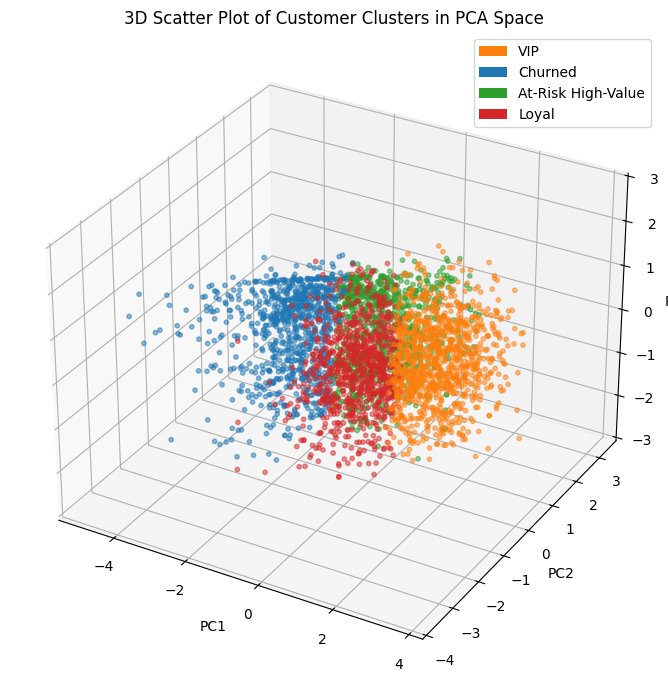

In [612]:
colors = non_outliers_df['Cluster'].map(cluster_labels_names).map(cluster_colors)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(projection='3d')

ax.scatter(pca_data[:, 0], 
           pca_data[:, 1], 
           pca_data[:, 2],
           c=colors,
           marker='o',
           alpha=0.5, s=10)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D Scatter Plot of Customer Clusters in PCA Space')

legend_elements = [Patch(facecolor=color, label=label) 
for label, color in cluster_colors.items()]

ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

THERE IS SOME SEPARATION BUT ALSO SIGNIFICANT OVERLAP, WHICH IS EXPECTED FOR CUSTOMER SEGMENTATION DATA.

VIP (ORANGE) SITS MOSTLY ON THE RIGHT — REASONABLE SEPARATION

CHURNED (BLUE) SITS MOSTLY ON THE LEFT — REASONABLY DISTINCT

LOYAL (RED) AND AT-RISK HIGH-VALUE (GREEN) OVERLAP HEAVILY WITH EACH OTHER AND WITH VIP

In [613]:
outlier_clusters_df = pd.concat([monetary_outliers_df, frequency_outliers_df, aov_outliers_df]).drop_duplicates()

print(outlier_clusters_df[["MonetaryValue", "Frequency", "Recency", "AOV"]].describe())

outlier_transformed = pt.transform(outlier_clusters_df[["MonetaryValue", "Frequency", "Recency", "Tenure", "AOV"]])
outlier_transformed_df = pd.DataFrame(outlier_transformed, columns=["MonetaryValue", "Frequency", "Recency", "Tenure", "AOV"])
outlier_transformed_df = outlier_transformed_df[["MonetaryValue", "Frequency", "Recency", "AOV"]]

outlier_pca = pca.transform(outlier_transformed_df)
outlier_clusters_df["Cluster"] = kmeans.predict(outlier_pca)

       MonetaryValue  Frequency  Recency      AOV
count         636.00     636.00   636.00   636.00
mean         8785.21      13.09    46.20   904.65
std         21595.18      17.52    67.18  1055.17
min           787.20       1.00     0.00    27.38
25%          2730.47       3.00     6.00   389.36
50%          4564.06      10.00    20.00   699.74
75%          7381.89      15.00    56.00  1036.41
max        349164.35     183.00   366.00 11880.84


In [614]:
full_clustering_df = pd.concat([
    non_outliers_df[["Cluster"]],
    outlier_clusters_df[["Cluster"]]
])

full_clustering_df["ClusterLabel"] = full_clustering_df["Cluster"].map(cluster_labels_names)
full_clustering_df

,Cluster,ClusterLabel
0,0,Churned
1,2,VIP
2,0,Churned
4,3,At-Risk High-Value
5,1,Loyal
...,...,...
3944,2,VIP
3975,2,VIP
3992,2,VIP
4061,3,At-Risk High-Value


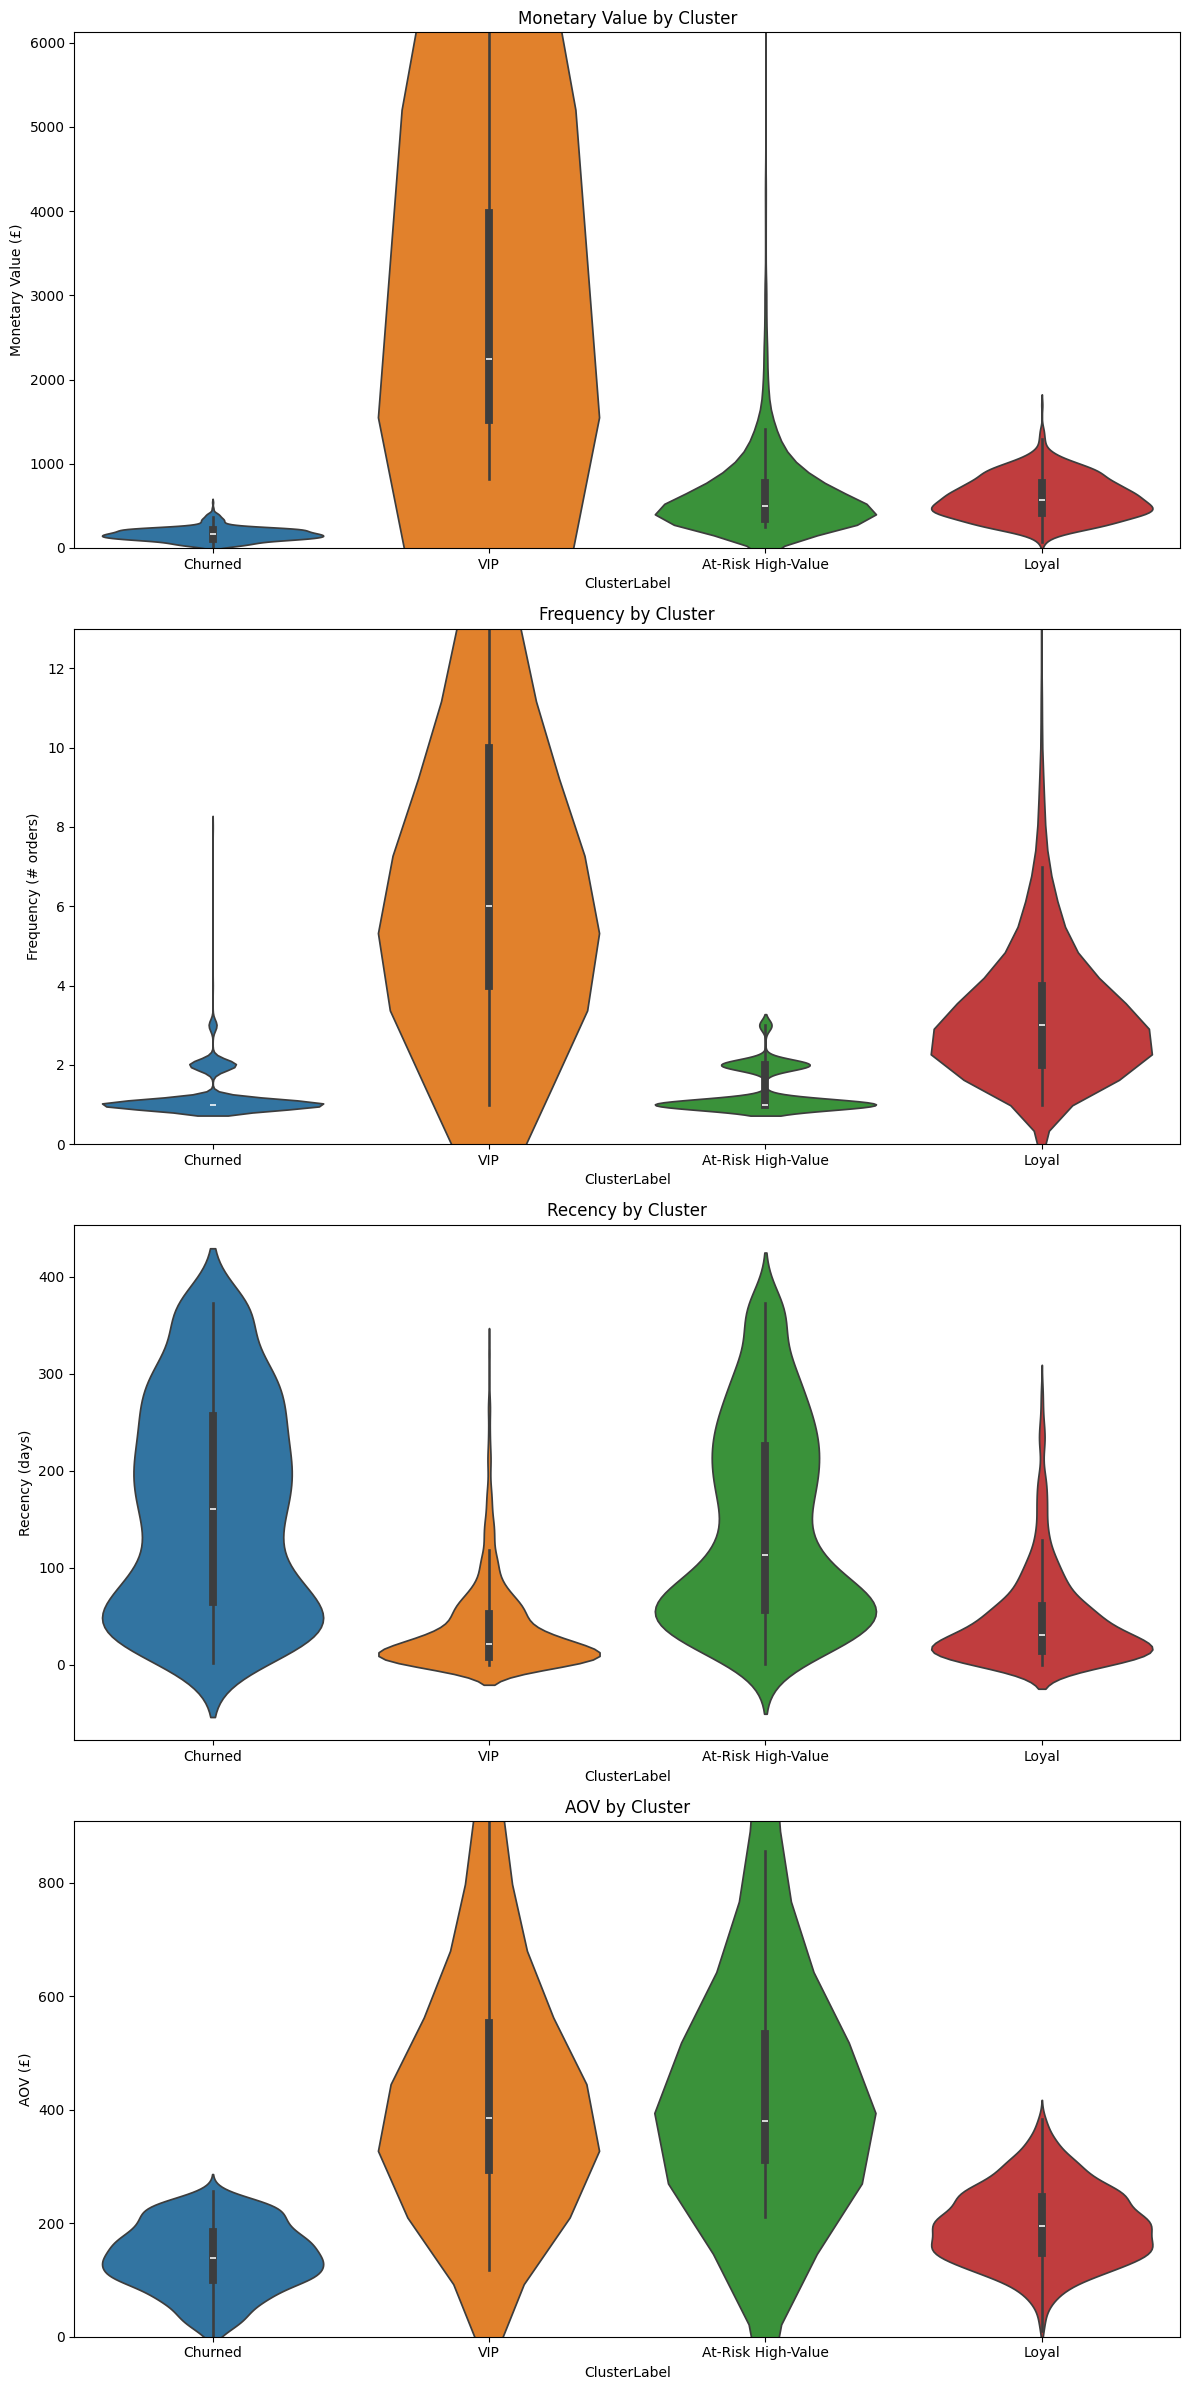

In [615]:
violin_df = aggregated_df.loc[aggregated_df.index.isin(full_clustering_df.index)].join(full_clustering_df['ClusterLabel'], how='inner')

plt.figure(figsize=(12, 24))

plt.subplot(4, 1, 1)
sns.violinplot(x=violin_df['ClusterLabel'], y=violin_df['MonetaryValue'], hue=violin_df['ClusterLabel'], palette=cluster_colors, legend=False)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value (£)')
plt.ylim(0, violin_df['MonetaryValue'].quantile(0.95))

plt.subplot(4, 1, 2)
sns.violinplot(x=violin_df['ClusterLabel'], y=violin_df['Frequency'], hue=violin_df['ClusterLabel'], palette=cluster_colors, legend=False)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency (# orders)')
plt.ylim(0, violin_df['Frequency'].quantile(0.95))

plt.subplot(4, 1, 3)
sns.violinplot(x=violin_df['ClusterLabel'], y=violin_df['Recency'], hue=violin_df['ClusterLabel'], palette=cluster_colors, legend=False)
plt.title('Recency by Cluster')
plt.ylabel('Recency (days)')

plt.subplot(4, 1, 4)
sns.violinplot(x=violin_df['ClusterLabel'], y=violin_df['AOV'], hue=violin_df['ClusterLabel'], palette=cluster_colors, legend=False)
plt.title('AOV by Cluster')
plt.ylabel('AOV (£)')
plt.ylim(0, violin_df['AOV'].quantile(0.95))

plt.tight_layout()
plt.show()

MONETARYVALUE — VIP CLEARLY HIGHEST, CHURNED LOWEST, WELL SEPARATED

FREQUENCY — VIP HIGHEST, AT-RISK VERY LOW (BOUGHT RARELY), CLEAR SEPARATION

RECENCY — CHURNED HIGHEST (HAVEN'T BOUGHT IN A LONG TIME), VIP LOWEST (BOUGHT RECENTLY)

AOV — VIP AND AT-RISK HIGH-VALUE BOTH HIGH, CHURNED AND LOYAL LOWER.

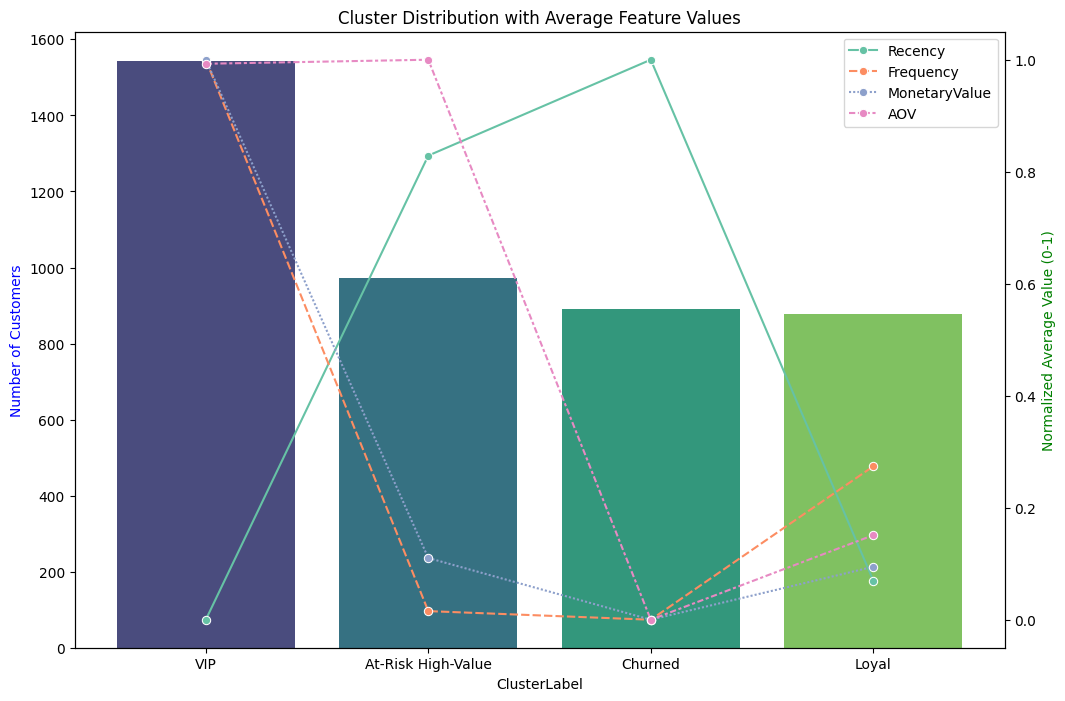

In [616]:
cluster_counts = full_clustering_df['ClusterLabel'].value_counts()

feature_means = violin_df.groupby('ClusterLabel')[['Recency', 'Frequency', 'MonetaryValue', 'AOV']].mean()
feature_means = feature_means.reindex(cluster_counts.index)

feature_means_viz = (feature_means - feature_means.min()) / (feature_means.max() - feature_means.min())
feature_means_viz = feature_means_viz.reindex(cluster_counts.index)

fig, ax1 = plt.subplots(figsize=(12, 8))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, ax=ax1, palette='viridis', hue=cluster_counts.index)
ax1.set_ylabel('Number of Customers', color='b')
ax1.set_title('Cluster Distribution with Average Feature Values')

ax2 = ax1.twinx()
sns.lineplot(data=feature_means_viz, ax=ax2, palette='Set2', marker='o')
ax2.set_ylabel('Normalized Average Value (0-1)', color='g')

plt.show()

In [617]:
print(feature_means)

                    Recency  Frequency  MonetaryValue    AOV
ClusterLabel                                                
VIP                   37.09       8.84        4741.00 516.97
At-Risk High-Value   143.01       1.35         669.61 519.71
Churned              164.90       1.23         165.43 139.94
Loyal                 46.03       3.32         598.35 197.28


In [618]:
print(full_clustering_df['ClusterLabel'].value_counts())

ClusterLabel
VIP                   1543
At-Risk High-Value     973
Churned                891
Loyal                  878
Name: count, dtype: int64


In [619]:
print(f"Non-outliers VIP: {(non_outliers_df['Cluster'] == vip_cluster).sum()}")
print(f"Outliers assigned to VIP: {(outlier_clusters_df['Cluster'] == vip_cluster).sum()}")
print(non_outliers_df[non_outliers_df["Cluster"] == vip_cluster][["MonetaryValue", "Frequency", "Recency", "AOV"]].describe())

Non-outliers VIP: 1013
Outliers assigned to VIP: 530
       MonetaryValue  Frequency  Recency     AOV
count        1013.00    1013.00  1013.00 1013.00
mean         1885.70       5.45    40.54  376.44
std           690.34       2.26    44.99  134.78
min           816.56       2.00     0.00  145.74
25%          1322.07       4.00    10.00  278.05
50%          1731.16       5.00    25.00  344.49
75%          2300.78       7.00    57.00  449.72
max          3786.70      11.00   314.00  780.23


VIP (1,543 CUSTOMERS) — 530 ARE STATISTICAL OUTLIERS,  BIG WHOLESALE/B2B BUYERS.

**FINAL BUSINESS RECOMMENDATIONS**:

VIP (1,543 CUSTOMERS | £4,768 AVG SPEND | 8.86 ORDERS | 37 DAYS RECENCY)
RETAIN AND REWARD. LAUNCH LOYALTY PROGRAMS, EARLY ACCESS TO NEW PRODUCTS, AND PERSONAL ACCOUNT MANAGERS FOR TOP SPENDERS. THESE CUSTOMERS DRIVE THE MOST REVENUE — PROTECT THEM AT ALL COSTS. 
NOTE: 530 ARE STATISTICAL OUTLIERS — LIKELY WHOLESALE/B2B BUYERS. 
CONSIDER DEDICATED ACCOUNT MANAGERS AND B2B PRICING FOR THIS SUBGROUP.

LOYAL (900 CUSTOMERS | £609 AVG SPEND | 3.34 ORDERS | 47 DAYS RECENCY)
NURTURE AND UPSELL. THEY BUY REGULARLY AND RECENTLY BUT SPEND LESS PER ORDER. CROSS-SELL COMPLEMENTARY PRODUCTS AND INTRODUCE THEM TO PREMIUM PRODUCT LINES TO MIGRATE THEM TOWARD VIP.

AT-RISK HIGH-VALUE (960 CUSTOMERS | £666 AVG SPEND | 1.34 ORDERS | 143 DAYS RECENCY)
RE-ENGAGE URGENTLY. HIGH AOV (£521) MEANS THEY SPEND WELL WHEN THEY DO BUY — THEY'RE WORTH SAVING. SEND PERSONALIZED WIN-BACK CAMPAIGNS, EXCLUSIVE DISCOUNTS, AND DIRECT OUTREACH BEFORE THEY CHURN COMPLETELY.
CHURNED (893 CUSTOMERS | £165 AVG SPEND | 1.23 ORDERS | 164 DAYS RECENCY)

LOW-COST RE-ENGAGEMENT ONLY. SEND AUTOMATED EMAIL CAMPAIGNS WITH STRONG INCENTIVES. IF NO RESPONSE AFTER 2-3 ATTEMPTS, DEPRIORITIZE — THE LOW MONETARY VALUE DOESN'T JUSTIFY HIGH MARKETING SPEND.

<h2 style="text-align: center">INFERENCE DEMO</h2>

In [620]:
print("vip_cluster:", vip_cluster)
print("cluster_labels_names:", cluster_labels_names)
print("cluster_means:\n", cluster_means)

vip_cluster: 2
cluster_labels_names: {np.int32(2): 'VIP', np.int32(0): 'Churned', np.int32(3): 'At-Risk High-Value', 1: 'Loyal'}
cluster_means:
          MonetaryValue  Frequency  Recency    AOV
Cluster                                          
0               165.43       1.23   164.90 139.94
1               595.60       3.22    46.15 197.72
2              1885.70       5.45    40.54 376.44
3               544.24       1.37   144.78 398.70


In [621]:
joblib.dump(pt, 'power_transformer.pkl')        # Yeo-Johnson transform
joblib.dump(pca, 'pca.pkl')                     # PCA (3 components)
joblib.dump(kmeans, 'kmeans_k4.pkl')            # trained model
joblib.dump(max_invoice_date, 'reference_date.pkl') 
joblib.dump(cluster_labels_names, 'cluster_labels_names.pkl')
joblib.dump({
    'M_Q1': M_Q1, 'M_Q3': M_Q3, 'M_IQR': M_IQR,
    'F_Q1': F_Q1, 'F_Q3': F_Q3, 'F_IQR': F_IQR,
    'AOV_Q1': AOV_Q1, 'AOV_Q3': AOV_Q3, 'AOV_IQR': AOV_IQR
}, 'iqr_bounds.pkl')                            # outlier thresholds

['iqr_bounds.pkl']

In [622]:
# Load artifacts
pt = joblib.load('power_transformer.pkl')
pca = joblib.load('pca.pkl')
kmeans = joblib.load('kmeans_k4.pkl')
iqr_bounds = joblib.load('iqr_bounds.pkl')
reference_date = joblib.load('reference_date.pkl')
cluster_labels_names = joblib.load('cluster_labels_names.pkl')

# New customers (raw values)
customers_raw = pd.DataFrame([
    {'last_purchase': '2010-11-20', 'MonetaryValue': 3000.0,  'Frequency': 10,  'Tenure': 400, 'AOV': 400.0},   # VIP
    {'last_purchase': '2010-11-10', 'MonetaryValue': 600.0,   'Frequency': 4,   'Tenure': 200, 'AOV': 150.0},   # Loyal
    {'last_purchase': '2010-07-01', 'MonetaryValue': 700.0,   'Frequency': 1,   'Tenure': 80,  'AOV': 600.0},   # At-Risk
    {'last_purchase': '2010-06-01', 'MonetaryValue': 150.0,   'Frequency': 1,   'Tenure': 30,  'AOV': 80.0},    # Churned
    {'last_purchase': '2010-09-01', 'MonetaryValue': 600.0,   'Frequency': 2,   'Tenure': 120, 'AOV': 450.0},   # Borderline
    {'last_purchase': '2010-11-20', 'MonetaryValue': 10000.0, 'Frequency': 100, 'Tenure': 500, 'AOV': 1000.0},  # Outlier
])

customers_raw['last_purchase'] = pd.to_datetime(customers_raw['last_purchase'])
customers_raw['Recency'] = (reference_date - customers_raw['last_purchase']).dt.days
customers = customers_raw[['MonetaryValue', 'Frequency', 'Recency', 'Tenure', 'AOV']]

# Outlier flag
def is_outlier(row):
    return (
        row['MonetaryValue'] > iqr_bounds['M_Q3'] + 1.5 * iqr_bounds['M_IQR'] or
        row['Frequency']     > iqr_bounds['F_Q3'] + 1.5 * iqr_bounds['F_IQR'] or
        row['AOV']           > iqr_bounds['AOV_Q3'] + 1.5 * iqr_bounds['AOV_IQR']
    )

customers_raw['is_outlier'] = customers.apply(is_outlier, axis=1)

# Transform
transformed = pt.transform(customers)
transformed_df = pd.DataFrame(transformed, columns=['MonetaryValue', 'Frequency', 'Recency', 'Tenure', 'AOV'])
transformed_df = transformed_df[['MonetaryValue', 'Frequency', 'Recency', 'AOV']]

# PCA + predict
pca_input = pca.transform(transformed_df)
clusters = kmeans.predict(pca_input)

labels = ['VIP', 'Loyal', 'At-Risk High-Value', 'Churned', 'Borderline', 'Outlier']
for i, cluster in enumerate(clusters):
    outlier_flag = '⚠️ OUTLIER' if customers_raw['is_outlier'].iloc[i] else ''
    print(f"Customer {i+1} ({labels[i]}): Cluster {cluster} — {cluster_labels_names[cluster]} {outlier_flag}")

Customer 1 (VIP): Cluster 2 — VIP 
Customer 2 (Loyal): Cluster 1 — Loyal 
Customer 3 (At-Risk High-Value): Cluster 3 — At-Risk High-Value 
Customer 4 (Churned): Cluster 0 — Churned 
Customer 5 (Borderline): Cluster 3 — At-Risk High-Value 
Customer 6 (Outlier): Cluster 2 — VIP ⚠️ OUTLIER


All 5 targeted customers landed exactly in their intended clusters, confirming the inference pipeline works correctly end-to-end. The outlier customer (Customer 6) was correctly classified as VIP by the model and flagged with ⚠️ OUTLIER, confirming the outlier detection pipeline also works.

Borderline case: High AOV (£450) and low Frequency (2) were the deciding 
factors — the model assigned this customer to At-Risk High-Value despite a 
moderate Recency of 99 days. This aligns with the cluster's core trait: 
customers who spend well per order but buy rarely, and is consistent with 
the Loyal/At-Risk overlap seen in the 3D scatter plot.

<h2 style="text-align: center">EXPORT</h2>

In [623]:
# Clustered customer data for marketing team
violin_df.to_excel('customer_segments.xlsx', index=True)

# Cluster summary statistics
feature_means.to_excel('cluster_summary.xlsx', index=True)

EXPORT TO EXCEL — FOR MARKETING AND MANAGEMENT TEAM

<h2 style="text-align: center">LIMITATIONS</h2>

LIMITATIONS:

1. SILHOUETTE SCORES ARE WEAK (0.27–0.36) — CUSTOMER BEHAVIOR IS INHERENTLY 
CONTINUOUS AND OVERLAP BETWEEN CLUSTERS IS EXPECTED.

2. DATA IS FROM 2009-2010 — MODEL MAY NOT GENERALIZE TO CURRENT CUSTOMER BEHAVIOR 
WITHOUT RETRAINING.

3. OUTLIERS (636 CUSTOMERS) ARE ASSIGNED VIA EXTRAPOLATION — THEIR CLUSTER 
ASSIGNMENTS ARE LESS RELIABLE THAN NON-OUTLIER CUSTOMERS.

4. MONETARYVALUE = AOV × FREQUENCY — ALGEBRAIC REDUNDANCY IN FEATURES, 
MITIGATED BY PCA DECORRELATION.